# Исследование рынка общественного питания Москвы

### Цели и задачи проекта

Целью проекта является изучение заведений общественного питания в Москве для выбора места открытия нового кафе/бара/ресторана инвесторами.
Задачи проекта:
1. Загрузка данных и ознакомление с ними.
2. Предобработка данных.
3. Исследование категорий заведений.
4. Выявление представленных районов города в данных.
5. Изучение соотношения сеетвых и несетевых заведений.
6. Исследование количества посадочных мест в заведениях.
7. Исследование рейтинга заведений.
8. Выявление топ-15 популярных сетей в Москве.
9. Изучение вариации среднего чека заведения.
10. Сформировать вывод и рекомендации для заказчика.

### Описание данных

Файл `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания:

- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — `5.0`);
- `chain` — число, выраженное `0` или `1`, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
    - `0` — заведение не является сетевым;
    - `1` — заведение является сетевым.
- `seats` — количество посадочных мест.

Файл `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:

- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
    - «Средний счёт: 1000–1500 ₽»;
    - «Цена чашки капучино: 130–220 ₽»;
    - «Цена бокала пива: 400–600 ₽».
        
        и так далее;
        
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

### Содержимое проекта

1. Загрузка данных и знакомство с ними
- 1.1 Промежуточный вывод
- 1.2 Подготовка единого датафрейма
2. Предобработка данных
- 2.1 Промежуточный вывод
3. Исследовательский анализ данных
- 3.1 Категории заведений
- 3.2 Административные районы Москвы
- 3.3 Сетевые и несетевые заведения
- 3.4 Количество посадочных мест
- 3.5 Рейтинг заведений
- 3.6 Корреляция рейтинга
- 3.7 Топ-15 популярных сетей
- 3.8 Вариация среднего чека
4. Итоговый вывод и рекомендации
- 4.1 Общий обзор проделанной работы
- 4.2 Главные выводы
- 4.3 Рекомендации

## 1. Загрузка данных и знакомство с ними

In [1]:
!pip install phik

     |████████████████████████████████| 677 kB 1.4 MB/s eta 0:00:01


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from scipy import stats
from scipy.stats import pearsonr, spearmanr, f_oneway, pointbiserialr
import phik
from phik.report import plot_correlation_matrix

In [3]:
df_ri = pd.read_csv('/datasets/rest_info.csv')
df_rf = pd.read_csv('/datasets/rest_price.csv')

In [4]:
df_ri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [5]:
df_ri.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [6]:
cols = ['category', 'district', 'hours', 'rating', 'chain']
for col in cols:
    print(f"Уникальные значения в {col}: {df_ri[col].unique()} в количестве {len(df_ri[col].unique())}")

Уникальные значения в category: ['кафе' 'ресторан' 'кофейня' 'пиццерия' 'бар,паб' 'быстрое питание'
 'булочная' 'столовая'] в количестве 8
Уникальные значения в district: ['Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Западный административный округ' 'Центральный административный округ'
 'Восточный административный округ' 'Юго-Восточный административный округ'
 'Южный административный округ' 'Юго-Западный административный округ'] в количестве 9
Уникальные значения в hours: ['ежедневно, 10:00–22:00'
 'пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00'
 'ежедневно, 09:00–22:00' ... 'пн-пт 08:30–21:30; сб,вс 09:00–21:30'
 'пн-чт 13:00–22:00; пт,сб 13:00–22:30; вс 13:00–22:00'
 'пн-сб 10:30–21:30'] в количестве 1308
Уникальные значения в rating: [5.  4.5 4.6 4.4 4.7 4.8 4.3 4.9 4.2 4.1 4.  3.8 3.9 3.7 3.6 2.8 2.7 3.1
 1.5 2.  1.4 3.3 3.5 3.2 2.9 3.  3.4 2.3 2.2 2.5 2.6 1.7 1.  1.1 2.4 1.3
 1.2 2.1 1.8 1.9 1.6] в 

In [7]:
df_rf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [8]:
df_rf.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [9]:
cols = ['price', 'avg_bill', 'middle_avg_bill', 'middle_coffee_cup']
for col in cols:
    print(f"Уникальные значения в {col}: {df_rf[col].unique()} в количестве {len(df_rf[col].unique())}")

Уникальные значения в price: ['выше среднего' 'средние' nan 'высокие' 'низкие'] в количестве 5
Уникальные значения в avg_bill: ['Средний счёт:1500–1600 ₽' 'Средний счёт:от 1000 ₽'
 'Цена чашки капучино:155–185 ₽' 'Средний счёт:400–600 ₽' nan
 'Средний счёт:199 ₽' 'Средний счёт:200–300 ₽' 'Средний счёт:от 500 ₽'
 'Средний счёт:1000–1200 ₽' 'Цена бокала пива:250–350 ₽'
 'Средний счёт:330 ₽' 'Средний счёт:1500 ₽' 'Средний счёт:300–500 ₽'
 'Средний счёт:140–350 ₽' 'Средний счёт:350–500 ₽'
 'Средний счёт:300–1500 ₽' 'Средний счёт:от 240 ₽'
 'Средний счёт:200–250 ₽' 'Средний счёт:328 ₽' 'Средний счёт:300 ₽'
 'Средний счёт:от 345 ₽' 'Средний счёт:60–400 ₽' 'Средний счёт:900 ₽'
 'Средний счёт:500–800 ₽' 'Средний счёт:500–1000 ₽'
 'Средний счёт:600–700 ₽' 'Цена бокала пива:120–350 ₽'
 'Средний счёт:1000–1500 ₽' 'Средний счёт:1500–2000 ₽'
 'Цена чашки капучино:150–190 ₽' 'Средний счёт:2000–2500 ₽'
 'Средний счёт:600 ₽' 'Средний счёт:450 ₽' 'Цена чашки капучино:120–170 ₽'
 'Средний счёт:100–500 ₽

---

### Промежуточный вывод

По датасету rest_info:
Здесь представлена основная информация о заведении: айди, название, категория, район, адрес, рейтинг, явлется ли сетью, количество посадочных мест. Столбцов 9, всего строк 8406. Почти все столбцы имеют формат object, рейтинг с количеством посадочных мест имеют тип float64, а столбец с информацией сетевое ли заведение имеет тип int64. Описанию данные соответствуют, у заведений даже есть айди по которому можно будет соединить данные из другой таблицы. Странно, что посадочные места имеют тип float64, а не int64. К остальным столбцам претензий нет, хотя инфо о рабочих часах можно было разбить на несколько столбцов (datetime + object, что-то подобное). Существует 8 категорий заведений, бар и паб это одна категория. Пропуски есть в часах работы и особенно в посадочных местах.

По датасету rest_price:
Здесь информация о ценах в некоторых заведениях: категория цен, средняя стоимость заказа в виде диапазона - иногда только по каким-либо напиткам или позициям, средний чек в виде числа, оценка стоимости чашки капучинно. Столбцов 5, а строк 4058 (меньше чем в датасете с инфо о заведениях). Айди, категория, средняя стоимость представлены в виде object, а средний чек и стоимость чашки кофе в float64. Данные соответствуют описанию. Всего существует 4 категории цен. Пропуски встречаются везде, кроме айди. Особенно мало данных о цене одной чашки капучино.

### Подготовка единого датафрейма

In [10]:
df = df_ri.merge(df_rf, on='id', how='left')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


In [12]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


Теперь информация из двух датасетов объединена. Но пропусков довольно много.

## 2. Предобработка данных

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


In [14]:
print(df.dtypes)

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                  int64
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object


In [15]:
df['chain'] = df['chain'].astype(bool)
df['category'] = df['category'].astype('category')
df['district'] = df['district'].astype('category')
df['price'] = df['price'].astype('category')
df.loc[df['seats'] == 0, 'seats'] = np.nan
df.loc[df['middle_avg_bill'] < 0, 'middle_avg_bill'] = np.nan
df.loc[df['middle_coffee_cup'] < 0, 'middle_coffee_cup'] = np.nan

In [16]:
rating_outliers = df[(df['rating'] < 0) | (df['rating'] > 5)]
if len(rating_outliers) > 0:
    print(f"Найдены некорректные рейтинги: {rating_outliers['rating'].unique()}")

In [17]:
print(df.dtypes)

id                     object
name                   object
category             category
address                object
district             category
hours                  object
rating                float64
chain                    bool
seats                 float64
price                category
avg_bill               object
middle_avg_bill       float64
middle_coffee_cup     float64
dtype: object


In [18]:
missing_stats = pd.DataFrame({
    'Кол-во пропусков': df.isnull().sum(),
    'Доля пропусков (%)': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0].sort_values('Кол-во пропусков', ascending=False)
print("Статистика пропущенных значений:")
print(missing_stats)

Статистика пропущенных значений:
                   Кол-во пропусков  Доля пропусков (%)
middle_coffee_cup              7871               93.64
middle_avg_bill                5257               62.54
price                          5091               60.56
avg_bill                       4590               54.60
seats                          3747               44.58
hours                           536                6.38


middle_coffee_cup - не в каждом заведении скорее всего подается чашка капучино, плюс в этот столбец записываются данные из avg_bill, где не всегда указано именно кофе.
middle_avg_bill - в avg_bill не всегда записывались данные о среднем чеке, поэтому в этот столбец часто ничего не входило.
price - не для каждого заведения выявлена ценовая категория, во втором датасете цен опять же было меньше строк, чем в первом с инфо о заведениях. Вероятно сервисом Яндекс Бизнес пользователи особо не пользуются, в основном Яндекс Картами.
avg_bill - наверное те же причины, что и у price.
seats - в некоторых заведениях не определили количество посадочных мест, возможно их количество нестабильно, либо сложно определить.
hours - пропусков не очень много, возможно пропуски имеют заведения 24/7.

In [19]:
print(f"Исходный размер датафрейма: {len(df)}")
df_c = df.copy()

Исходный размер датафрейма: 8406


In [21]:
print(f"\nПропуски в seats до заполнения: {df['seats'].isna().sum()}")

df['seats'] = df.groupby('category')['seats'].transform(
    lambda x: x.fillna(x.median())
)

if df['seats'].isna().sum() > 0:
    overall_median = df['seats'].median()
    df['seats'].fillna(overall_median, inplace=True)
    print(f"Оставшиеся пропуски заполнены общей медианой: {overall_median}")

df['seats'] = df['seats'].round().astype(int)

print(f"Пропуски в seats после заполнения: {df['seats'].isna().sum()}")
print(f"Статистика seats: min={df['seats'].min()}, max={df['seats'].max()}, median={df['seats'].median()}")


Пропуски в seats до заполнения: 3747
Пропуски в seats после заполнения: 0
Статистика seats: min=1, max=1288, median=80.0


In [25]:
missing_final = df.isnull().sum()
missing_final = missing_final[missing_final > 0]

if len(missing_final) > 0:
    print("Оставшиеся пропуски:")
    print(missing_final)
else:
    print("Все запланированные пропуски успешно обработаны")


print(f"\nПроверка price: все ли значения из допустимого набора?")
valid_price = ['выше среднего', 'средние', 'высокие', 'низкие']
invalid_price = df[~df['price'].isin(valid_price)]
if len(invalid_price) > 0:
    print(f"Найдены некорректные значения: {invalid_price['price'].unique()}")
else:
    print("Все значения price корректны")


if (df['seats'] < 0).any():
    print(f"Найдены отрицательные значения seats: {df[df['seats'] < 0]['seats'].unique()}")
else:
    print("Все значения seats неотрицательны")

Оставшиеся пропуски:
hours                 536
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

Проверка price: все ли значения из допустимого набора?
Найдены некорректные значения: [NaN]
Categories (0, object): []
Все значения seats неотрицательны


In [26]:
print("Пропуски:")
comparison = pd.DataFrame({
    'Исходные данные': df_c.isnull().sum(),
    'После обработки': df.isnull().sum()
})

print(comparison[comparison['Исходные данные'] > 0])


print(f"Размер датафрейма: {df.shape}")
print(f"\nТипы данных:\n{df.dtypes}")

Пропуски:
                   Исходные данные  После обработки
hours                          536              536
seats                         3747                0
price                         5091             5091
avg_bill                      4590             4590
middle_avg_bill               5257             5257
middle_coffee_cup             7871             7871
Размер датафрейма: (8406, 13)

Типы данных:
id                     object
name                   object
category             category
address                object
district             category
hours                  object
rating                float64
chain                    bool
seats                   int64
price                category
avg_bill               object
middle_avg_bill       float64
middle_coffee_cup     float64
dtype: object


In [27]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,False,60,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,False,4,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,False,45,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,False,80,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,True,148,средние,Средний счёт:400–600 ₽,500.0,NaN


In [28]:
def normalize_text(text):
    if pd.isna(text):
        return text
    
    text = str(text).lower().strip()
    
    text = re.sub(r'[^\w\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
    
    suffixes = [
        r'\s+кафе$', r'\s+ресторан$', r'\s+бар$', r'\s+кофейня$',
        r'\s+пиццерия$', r'\s+столовая$', r'\s+булочная$', r'\s+фастфуд$'
    ]
    for suffix in suffixes:
        text = re.sub(suffix, '', text)
    
    return text

def normalize_address(address):
    if pd.isna(address):
        return address
    
    address = str(address).lower().strip()
    replacements = {
        'ул\.': 'улица', 'улица': 'улица',
        'пр\.': 'проспект', 'проспект': 'проспект',
        'пл\.': 'площадь', 'площадь': 'площадь',
        'пер\.': 'переулок', 'переулок': 'переулок',
        'б-р': 'бульвар', 'бульвар': 'бульвар',
        'наб\.': 'набережная', 'набережная': 'набережная',
        'ш\.': 'шоссе', 'шоссе': 'шоссе'
    }
    
    for old, new in replacements.items():
        address = address.replace(old, new)
        
    address = re.sub(r'[^\w\s]', '', address)
    address = re.sub(r'\s+', ' ', address).strip()
    
    return address

df['name'] = df['name'].apply(normalize_text)
df['address'] = df['address'].apply(normalize_address)

print("Нормализация завершена")
print(f"Пример нормализации названия:\n{df['name'].iloc[0:5]}''")
print(f"Пример нормализации адреса:\n{df['address'].iloc[0:5]}'")

Нормализация завершена
Пример нормализации названия:
0                  wowфли
1          четыре комнаты
2                   хазри
3    dormouse coffee shop
4               иль марко
Name: name, dtype: object''
Пример нормализации адреса:
0              москва улица дыбенко 71
1       москва улица дыбенко 36 корп 1
2         москва клязьминская улица 15
3    москва улица маршала федоренко 12
4        москва правобережная улица 1б
Name: address, dtype: object'


In [29]:
exact_duplicates = df[df.duplicated(keep=False)]
exact_duplicates_count = len(exact_duplicates)

print(f"Найдено полных дубликатов строк: {exact_duplicates_count}")
if exact_duplicates_count > 0:
    print(f"Количество уникальных дублирующихся записей: {len(exact_duplicates.groupby(list(df.columns)))}")
    print("\nПримеры полных дубликатов (первые 3 группы):")
    for _, group in exact_duplicates.groupby(list(df.columns)).head(3):
        print(f"\nДубликаты (первые 2):")
        print(group[['name', 'address', 'category']].head(2))

Найдено полных дубликатов строк: 0


In [30]:
df['duplicate_key'] = df['name'] + ' | ' + df['address']

name_address_duplicates = df[df.duplicated(subset=['duplicate_key'], keep=False)]

print(f"Найдено записей с дублирующимися (название+адрес): {len(name_address_duplicates)}")
print(f"Количество групп дубликатов: {name_address_duplicates['duplicate_key'].nunique()}")

if len(name_address_duplicates) > 0:
    print("\nПримеры неявных дубликатов (первые 5 групп):")
    
    for i, (key, group) in enumerate(name_address_duplicates.groupby('duplicate_key')):
        if i >= 5:
            break
        print(f"\nГруппа {i+1}:")
        print(f"  Ключ: {key[:100]}...")
        print(f"  Количество записей: {len(group)}")
        print("  Записи:")
        for _, row in group.iterrows():
            print(f"    - {row['name']} | {row['address']} | рейтинг: {row['rating']} | id: {row['id']}")

Найдено записей с дублирующимися (название+адрес): 10
Количество групп дубликатов: 5

Примеры неявных дубликатов (первые 5 групп):

Группа 1:
  Ключ: more poke | москва волоколамское шоссе 11 стр 2...
  Количество записей: 2
  Записи:
    - more poke | москва волоколамское шоссе 11 стр 2 | рейтинг: 4.2 | id: 62608690e9cc464fbcd980cfd552e334
    - more poke | москва волоколамское шоссе 11 стр 2 | рейтинг: 4.2 | id: a69f018d5c064873a3b491b0121bc1b4

Группа 2:
  Ключ: в парке вкуснее | москва северный административный округ район левобережный территория парка дружбы...
  Количество записей: 2
  Записи:
    - в парке вкуснее | москва северный административный округ район левобережный территория парка дружбы | рейтинг: 2.2 | id: be007021c2a44e2f9488f7b3174d1a2b
    - в парке вкуснее | москва северный административный округ район левобережный территория парка дружбы | рейтинг: 2.2 | id: 82ea6220bb4e4ffe83bfdf1dd7b4d556

Группа 3:
  Ключ: кафе | москва парк ангарские пруды...
  Количество зап

In [31]:
name_groups = df.groupby('name').size().sort_values(ascending=False)

duplicate_names = name_groups[name_groups > 1]

print(f"Всего уникальных названий: {df['name'].nunique()}")
print(f"Названий, встречающихся >1 раза: {len(duplicate_names)}")
print(f"Максимальное количество повторений: {duplicate_names.max()}")

print("\nТоп-10 самых частых названий:")
for name, count in duplicate_names.head(10).items():
    original_names = df[df['name'] == name]['name'].unique()
    print(f"  '{original_names[0]}' (всего {count} заведений)")


Всего уникальных названий: 5472
Названий, встречающихся >1 раза: 766
Максимальное количество повторений: 194

Топ-10 самых частых названий:
  'кафе' (всего 194 заведений)
  'шоколадница' (всего 120 заведений)
  'доминос пицца' (всего 78 заведений)
  'додо пицца' (всего 74 заведений)
  'one price coffee' (всего 72 заведений)
  'яндекс лавка' (всего 69 заведений)
  'cofix' (всего 65 заведений)
  'prime' (всего 50 заведений)
  'шаурма' (всего 44 заведений)
  'хинкальная' (всего 44 заведений)


In [32]:
address_groups = df.groupby('address').size().sort_values(ascending=False)
duplicate_addresses = address_groups[address_groups > 1]

print(f"Всего уникальных адресов: {df['address'].nunique()}")
print(f"Адресов, где несколько заведений: {len(duplicate_addresses)}")
print(f"Максимум заведений по одному адресу: {duplicate_addresses.max()}")

print("\nТоп-10 адресов с наибольшим количеством заведений:")
for address, count in duplicate_addresses.head(10).items():
    places = df[df['address'] == address][['name', 'category']].head(3)
    print(f"\n  Адрес: {address[:80]}... ({count} заведений)")
    print(f"    Примеры: {', '.join(places['name'].head(3).values)}")

Всего уникальных адресов: 5751
Адресов, где несколько заведений: 1356
Максимум заведений по одному адресу: 28

Топ-10 адресов с наибольшим количеством заведений:

  Адрес: москва проспект вернадского 86в... (28 заведений)
    Примеры: паrk фудхолл, i need doner, fibo pasta ravioli

  Адрес: москва усачёва улица 26... (26 заведений)
    Примеры: сыроварня, nafa grill, frank by баста

  Адрес: москва площадь киевского вокзала 2... (20 заведений)
    Примеры: хлеб насущный, osteria mario, vasilchukí chaihona 1

  Адрес: москва ярцевская улица 19... (20 заведений)
    Примеры: хачапури, мясорыба, находка

  Адрес: москва щёлковское шоссе вл75... (16 заведений)
    Примеры: кафе натахтари, шеф kebab steak, сыроварня

  Адрес: москва лесная улица 20 стр 3... (16 заведений)
    Примеры: soul in the bowl, бансонс бургер китчен, ktown korean bbq

  Адрес: москва пресненская набережная 2... (16 заведений)
    Примеры: udcкафе, мясорыба, osteria mario

  Адрес: москва проспект мира 211к2... (16 з

In [33]:
if len(name_address_duplicates) > 0:
    rating_differences = []
    
    for key, group in name_address_duplicates.groupby('duplicate_key'):
        if len(group) > 1:
            ratings = group['rating'].values
            max_rating = ratings.max()
            min_rating = ratings.min()
            rating_differences.append(max_rating - min_rating)
    
    if rating_differences:
        print(f"Средняя разница в рейтинге между дубликатами: {np.mean(rating_differences):.2f}")
        print(f"Максимальная разница: {np.max(rating_differences):.2f}")
        
        for key, group in name_address_duplicates.groupby('duplicate_key'):
            if len(group) > 1 and group['rating'].max() - group['rating'].min() > 2:
                print(f"\nБольшая разница в рейтинге для:")
                print(f"  Ключ: {key[:80]}...")
                for _, row in group.iterrows():
                    print(f"    - {row['name']} | рейтинг: {row['rating']} | id: {row['id']}")

Средняя разница в рейтинге между дубликатами: 0.00
Максимальная разница: 0.00


In [34]:
duplicates_to_remove = []

for key, group in name_address_duplicates.groupby('duplicate_key'):
    if len(group) > 1:
        best_idx = group['rating'].idxmax()
        for idx in group.index:
            if idx != best_idx:
                duplicates_to_remove.append(idx)

print(f"Будет удалено дубликатов: {len(duplicates_to_remove)}")

df = df.drop(index=duplicates_to_remove)

print(f"\nФинальный размер датафрейма: {len(df)}")


Будет удалено дубликатов: 5

Финальный размер датафрейма: 8401


In [35]:
del df['duplicate_key']

In [36]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,москва улица дыбенко 71,Северный административный округ,"ежедневно, 10:00–22:00",5.0,False,60,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,москва улица дыбенко 36 корп 1,Северный административный округ,"ежедневно, 10:00–22:00",4.5,False,4,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,хазри,кафе,москва клязьминская улица 15,Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,False,45,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,москва улица маршала федоренко 12,Северный административный округ,"ежедневно, 09:00–22:00",5.0,False,80,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,москва правобережная улица 1б,Северный административный округ,"ежедневно, 10:00–22:00",5.0,True,148,средние,Средний счёт:400–600 ₽,500.0,NaN


In [37]:
def is_24_7(hours_str):
    if pd.isna(hours_str):
        return False
    
    hours_lower = str(hours_str).lower().strip()
    
    has_specific_days = bool(re.search(r'(пн|вт|ср|чт|пт|сб|вс|пн-пт|пн-чт|пт-сб)', hours_lower))
    
    time_pattern = r'(\d{1,2}:\d{2})\s*[-–]\s*(\d{1,2}:\d{2})'
    matches = re.findall(time_pattern, hours_lower)
    
    has_non_midnight_time = False
    for start, end in matches:
        if start != '00:00' and start != '0:00' and end != '00:00' and end != '0:00':
            has_non_midnight_time = True
            break
    
    has_weekend_exceptions = bool(re.search(r'(выходные|праздник|кроме)', hours_lower))
    
    if has_specific_days or has_non_midnight_time or has_weekend_exceptions:
        return False
    
    patterns_247 = [
        r'24[/-]7',
        r'круглосуточно',
        r'24\s*часа',
        r'00:00[-–]00:00',
        r'0:00[-–]0:00'
    ]
    
    for pattern in patterns_247:
        if re.search(pattern, hours_lower):
            return True
    
    return False

df['is_24_7'] = df['hours'].apply(is_24_7)

print(f"Создан столбец is_24_7")
print(f"Количество круглосуточных заведений: {df['is_24_7'].sum()}")
print(f"Доля круглосуточных: {df['is_24_7'].mean()*100:.2f}%")

true_247 = df[df['is_24_7'] == True]['hours'].unique()
print(f"\nНайдено {len(true_247)} уникальных вариантов написания 24/7:")
for val in true_247[:10]:
    print(f"  - {val}")

false_cases = df[(df['hours'].str.contains('круглосуточно', case=False, na=False)) & (df['is_24_7'] == False)]['hours'].unique()
if len(false_cases) > 0:
    print(f"\nЗначения с 'круглосуточно', но НЕ определенные как 24/7:")
    for val in false_cases[:5]:
        print(f"  - {val}")
else:
    print("\nВсе значения с 'круглосуточно' корректно определены как 24/7")
    
print("\nПримеры круглосуточных заведений:")
display(df[df['is_24_7'] == True][['name', 'category', 'hours', 'is_24_7']].head(30))

print("\nПримеры НЕ круглосуточных заведений:")
display(df[df['is_24_7'] == False][['name', 'category', 'hours', 'is_24_7']].head(30))

Создан столбец is_24_7
Количество круглосуточных заведений: 730
Доля круглосуточных: 8.69%

Найдено 1 уникальных вариантов написания 24/7:
  - ежедневно, круглосуточно

Значения с 'круглосуточно', но НЕ определенные как 24/7:
  - пн 00:01–12:00, перерыв 12:00–13:30; вт-чт 13:30–12:00; пт 13:30–00:00; сб,вс круглосуточно
  - вт-вс круглосуточно
  - сб круглосуточно
  - пт-вс круглосуточно
  - пн,ср,чт,пт,сб,вс круглосуточно

Примеры круглосуточных заведений:


,name,category,hours,is_24_7
10,great room bar,"бар,паб","ежедневно, круглосуточно",True
17,чайхана бешбармак,ресторан,"ежедневно, круглосуточно",True
19,пекарня,булочная,"ежедневно, круглосуточно",True
24,drive café,кафе,"ежедневно, круглосуточно",True
49,2uтую,пиццерия,"ежедневно, круглосуточно",True
50,шаурма,быстрое питание,"ежедневно, круглосуточно",True
54,шашлык,быстрое питание,"ежедневно, круглосуточно",True
61,кафе лоза,ресторан,"ежедневно, круглосуточно",True
70,гуава,"бар,паб","ежедневно, круглосуточно",True
84,meat doner kebab,булочная,"ежедневно, круглосуточно",True



Примеры НЕ круглосуточных заведений:


,name,category,hours,is_24_7
0,wowфли,кафе,"ежедневно, 10:00–22:00",False
1,четыре комнаты,ресторан,"ежедневно, 10:00–22:00",False
2,хазри,кафе,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",False
3,dormouse coffee shop,кофейня,"ежедневно, 09:00–22:00",False
4,иль марко,пиццерия,"ежедневно, 10:00–22:00",False
5,sergio pizza,пиццерия,"ежедневно, 10:00–23:00",False
6,огни города,"бар,паб",пн 15:00–04:00; вт-вс 15:00–05:00,False
7,mr уголёк,быстрое питание,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",False
8,donna maria,ресторан,"ежедневно, 10:00–22:00",False
9,готика,кафе,"ежедневно, 12:00–00:00",False


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8401 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 8401 non-null   object  
 1   name               8401 non-null   object  
 2   category           8401 non-null   category
 3   address            8401 non-null   object  
 4   district           8401 non-null   category
 5   hours              7866 non-null   object  
 6   rating             8401 non-null   float64 
 7   chain              8401 non-null   bool    
 8   seats              8401 non-null   int64   
 9   price              3315 non-null   category
 10  avg_bill           3816 non-null   object  
 11  middle_avg_bill    3149 non-null   float64 
 12  middle_coffee_cup  535 non-null    float64 
 13  is_24_7            8401 non-null   bool    
dtypes: bool(2), category(3), float64(3), int64(1), object(5)
memory usage: 698.3+ KB


In [39]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,москва улица дыбенко 71,Северный административный округ,"ежедневно, 10:00–22:00",5.0,False,60,NaN,NaN,NaN,NaN,False
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,москва улица дыбенко 36 корп 1,Северный административный округ,"ежедневно, 10:00–22:00",4.5,False,4,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,False
2,1070b6b59144425896c65889347fcff6,хазри,кафе,москва клязьминская улица 15,Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,False,45,средние,Средний счёт:от 1000 ₽,1000.0,NaN,False
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,москва улица маршала федоренко 12,Северный административный округ,"ежедневно, 09:00–22:00",5.0,False,80,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0,False
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,москва правобережная улица 1б,Северный административный округ,"ежедневно, 10:00–22:00",5.0,True,148,средние,Средний счёт:400–600 ₽,500.0,NaN,False


---

### Промежуточный вывод

Перед предобработкой данных имели:
- 13 столбцов, 8406 строк.
- Пропуски: middle_coffee_cup - 7871 (93.64%), middle_avg_bill - 5257 (62.54%), price - 5091 (60.56%), avg_bill - 4590 (54.60%), seats - 3747 (44.58%), hours -  536 (6.38%).

После предобработки:
- 14 столбцов, 8401 строк.
- Обработаны пропуски. seats заполнены по категории заведения. Пропуски оставлены в остальных столбцах.
- Тип данных некоторых столбцов преобразован в более подходящий: category -> тип category, district -> category, chain -> bool, seats -> int64, price -> category.
- Адреса и названия нормализованы, все буквы строчные, удалены знаки препинания.
- Обработаны явные и неявные дубликаты. Явных дубликатов не обнаружено, но найдено 8 неявных. 4 дублирующих строки удалены.
- Создан новый столбец is_24_7. Выявлены круглосуточные и ежедневные заведения, которых 8.69% от общего количества.

Теперь данные готовы для дальнейшего исследования. Важные пропуски заполнены, дубликатов не осталось.

## 3. Исследовательский анализ данных

---

### Категории заведений

In [40]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

categories = df['category'].value_counts()
categories = categories.sort_values(ascending=True)
print(f"\nВсего категорий: {len(categories)}")
print(f"\nРаспределение по категориям:")
print(categories)

print(f"\nОсновная статистика:")
print(f"  Самая популярная категория: {categories.index[0]} ({categories.iloc[0]} заведений)")
print(f"  Самая редкая категория: {categories.index[-1]} ({categories.iloc[-1]} заведений)")
print(f"  Среднее количество заведений в категории: {categories.mean():.1f}")


Всего категорий: 8

Распределение по категориям:
булочная            256
столовая            315
быстрое питание     603
пиццерия            633
бар,паб             764
кофейня            1412
ресторан           2042
кафе               2376
Name: category, dtype: int64

Основная статистика:
  Самая популярная категория: булочная (256 заведений)
  Самая редкая категория: кафе (2376 заведений)
  Среднее количество заведений в категории: 1050.1


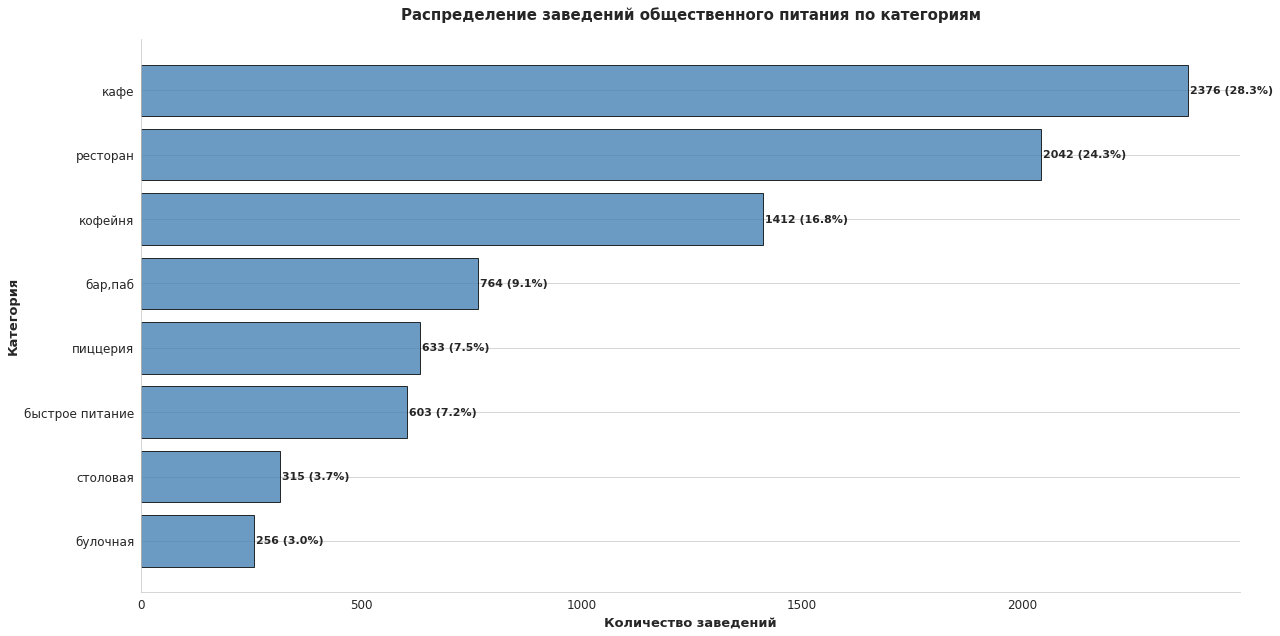

In [41]:
fig, ax = plt.subplots(figsize=(18, 9))

bars = ax.barh(categories.index, categories.values, color='steelblue', edgecolor='black', alpha=0.8)

for i, (bar, value) in enumerate(zip(bars, categories.values)):
    ax.text(value + 5, bar.get_y() + bar.get_height()/2, 
            f'{value} ({value/len(df)*100:.1f}%)', 
            va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Количество заведений', fontsize=13, fontweight='bold')
ax.set_ylabel('Категория', fontsize=13, fontweight='bold')
ax.set_title('Распределение заведений общественного питания по категориям', 
             fontsize=15, fontweight='bold', pad=20)

ax.grid(axis='x', alpha=0.3, linestyle='--')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Как видно, больше всего представлено заведения типа кафе (2376 шт.), на втором месте тип ресторан (2042 шт.), на третьем кофейня (1412 шт.). Меньше всего булочных (256 шт.) и столовых (315 шт.) - вероятно не слишком востребованный и прибыльный тип заведений. Быстрое питание (603 шт.), пиццерии (633 шт.) и бары/пабы (764 шт.) находятся в золотой середине.

---

### Районы Москвы

In [42]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (18, 9)

districts = df['district'].value_counts()
print(f"\nВсего районов: {len(districts)}")
print(f"\nРаспределение заведений по районам:")
print(districts)

print(f"\nСтатистика:")
print(f"  Самый насыщенный район: {districts.index[0]} ({districts.iloc[0]} заведений)")
print(f"  Самый ненасыщенный район: {districts.index[-1]} ({districts.iloc[-1]} заведений)")
print(f"  Среднее количество: {districts.mean():.1f} заведений на район")


Всего районов: 9

Распределение заведений по районам:
Центральный административный округ         2242
Северный административный округ             897
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

Статистика:
  Самый насыщенный район: Центральный административный округ (2242 заведений)
  Самый ненасыщенный район: Северо-Западный административный округ (409 заведений)
  Среднее количество: 933.4 заведений на район


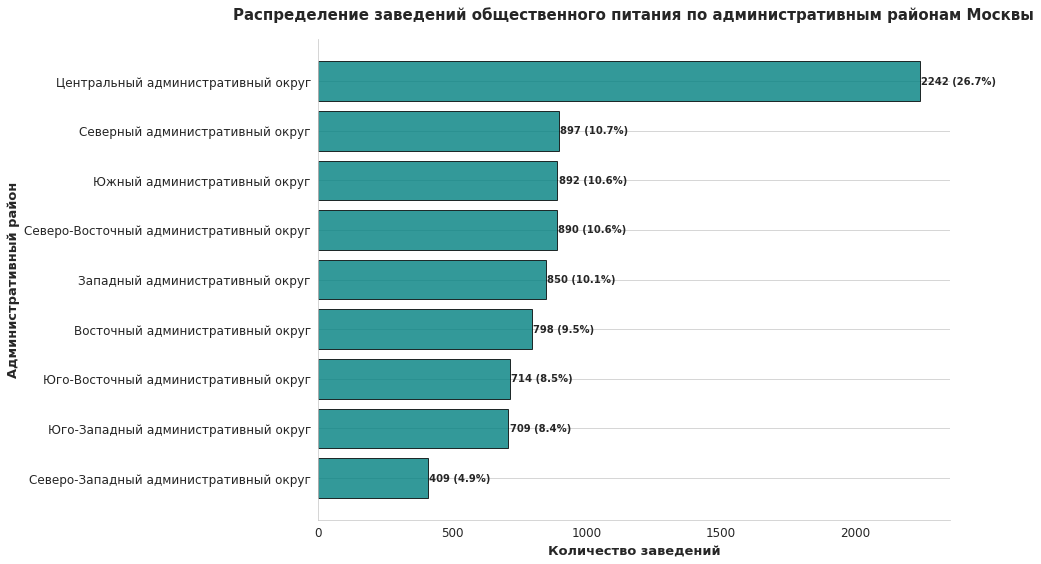

In [43]:
fig, ax = plt.subplots(figsize=(14, 8))

districts_sorted = districts.sort_values(ascending=True)

bars = ax.barh(districts_sorted.index, districts_sorted.values, 
               color='teal', edgecolor='black', alpha=0.8)

for bar, value in zip(bars, districts_sorted.values):
    ax.text(value + 5, bar.get_y() + bar.get_height()/2,
            f'{value} ({value/len(df)*100:.1f}%)',
            va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Количество заведений', fontsize=13, fontweight='bold')
ax.set_ylabel('Административный район', fontsize=13, fontweight='bold')
ax.set_title('Распределение заведений общественного питания по административным районам Москвы',
             fontsize=15, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [44]:
cao_data = df[df['district'] == 'Центральный административный округ']
cao_categories = cao_data['category'].value_counts()

print(f"\nКоличество заведений в ЦАО: {len(cao_data)}")
print(f"Доля от всех заведений: {len(cao_data)/len(df)*100:.1f}%")

print(f"\nРаспределение по категориям в ЦАО:")
print(cao_categories)

comparison = pd.DataFrame({
    'ЦАО': cao_categories,
    'Вся Москва': df['category'].value_counts()
}).fillna(0)
comparison['ЦАО_доля'] = comparison['ЦАО'] / len(cao_data) * 100
comparison['Москва_доля'] = comparison['Вся Москва'] / len(df) * 100
comparison['Разница'] = comparison['ЦАО_доля'] - comparison['Москва_доля']

print("\nСравнение долей категорий в ЦАО и в целом по Москве:")
print(comparison[['ЦАО_доля', 'Москва_доля', 'Разница']].round(1))


Количество заведений в ЦАО: 2242
Доля от всех заведений: 26.7%

Распределение по категориям в ЦАО:
ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

Сравнение долей категорий в ЦАО и в целом по Москве:
                 ЦАО_доля  Москва_доля  Разница
бар,паб              16.2          9.1      7.1
булочная              2.2          3.0     -0.8
быстрое питание       3.9          7.2     -3.3
кафе                 20.7         28.3     -7.6
кофейня              19.1         16.8      2.3
пиццерия              5.0          7.5     -2.5
ресторан             29.9         24.3      5.6
столовая              2.9          3.7     -0.8


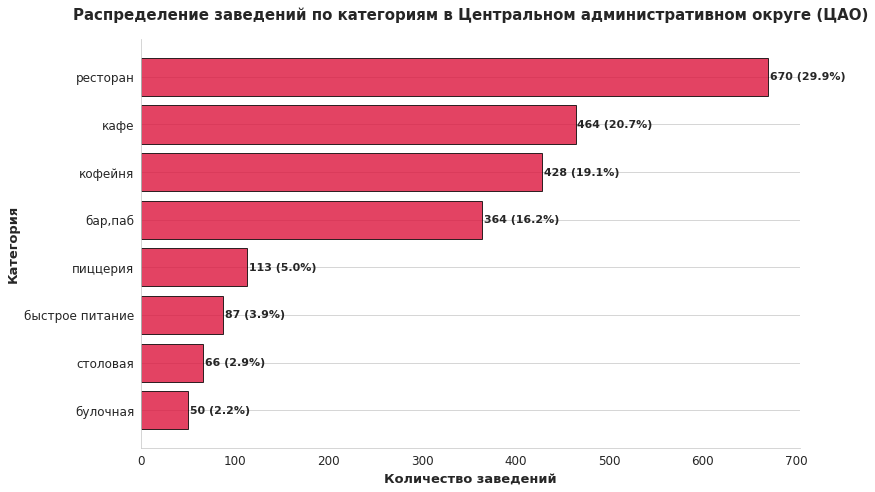

In [45]:
fig, ax = plt.subplots(figsize=(12, 7))

cao_categories_sorted = cao_categories.sort_values(ascending=True)

bars = ax.barh(cao_categories_sorted.index, cao_categories_sorted.values,
               color='crimson', edgecolor='black', alpha=0.8)

for bar, value in zip(bars, cao_categories_sorted.values):
    ax.text(value + 2, bar.get_y() + bar.get_height()/2,
            f'{value} ({value/len(cao_data)*100:.1f}%)',
            va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Количество заведений', fontsize=13, fontweight='bold')
ax.set_ylabel('Категория', fontsize=13, fontweight='bold')
ax.set_title('Распределение заведений по категориям в Центральном административном округе (ЦАО)',
             fontsize=15, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

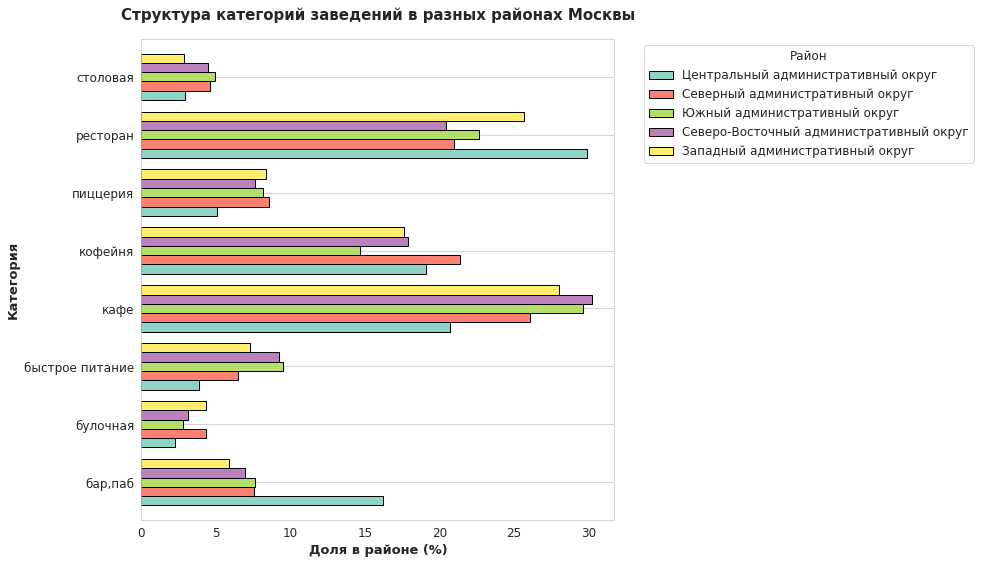

In [46]:
districts_comparison = df.groupby('district')['category'].value_counts().unstack(fill_value=0)

districts_normalized = districts_comparison.div(districts_comparison.sum(axis=1), axis=0) * 100

top_districts_list = districts.head(5).index.tolist()
if 'Центральный административный округ' not in top_districts_list:
    top_districts_list.append('Центральный административный округ')
    
districts_to_plot = districts_normalized.loc[top_districts_list]

fig, ax = plt.subplots(figsize=(14, 8))

districts_to_plot.T.plot(kind='barh', ax=ax, width=0.8, 
                          colormap='Set3', edgecolor='black')

ax.set_xlabel('Доля в районе (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Категория', fontsize=13, fontweight='bold')
ax.set_title('Структура категорий заведений в разных районах Москвы',
             fontsize=15, fontweight='bold', pad=20)
ax.legend(title='Район', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

Больше всего заведение, как нестранно, в Центральном административном округе (2211 шт.), а меньше всего в Северо-Западном административном округе (369 шт.). В остальных округах значения близки друг к другу, в диапазоне 629-843 шт.

В ЦАО больше всего ресторанов (665 шт.), на втором месте кафе (444 шт.), на третьем кофейни (426 шт.). Очень мало столовых (65 шт.) и булочных (50 шт.). Бары с пабами (364 шт.) не сильно отстают от кофеен. Всё для продуктивного дня и хорошего вечернего отдыха.

По сравнению с другими округами, в ЦАО больше всего преобладают рестораны и бары с пабами. В других районах преобладают другие типы заведений. Даже доля кафе больше в Северо-Восточном округе и доля кофеен больше в Северном округе.

---

### Изучение сетевых и несетевых заведений

In [47]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (18, 9)

chain_counts = df['chain'].value_counts()
chain_percent = df['chain'].value_counts(normalize=True) * 100

print(f"\nОбщая статистика:")
print(f"  Сетевых заведений: {chain_counts[True]} ({chain_percent[True]:.1f}%)")
print(f"  Несетевых заведений: {chain_counts[False]} ({chain_percent[False]:.1f}%)")
print(f"  Всего заведений: {len(df)}")

if chain_counts[True] > chain_counts[False]:
    print(f"\nСетевых заведений больше на {chain_counts[True] - chain_counts[False]} ({chain_percent[True] - chain_percent[False]:.1f}%)")
else:
    print(f"\nНесетевых заведений больше на {chain_counts[False] - chain_counts[True]} ({chain_percent[False] - chain_percent[True]:.1f}%)")


Общая статистика:
  Сетевых заведений: 3202 (38.1%)
  Несетевых заведений: 5199 (61.9%)
  Всего заведений: 8401

Несетевых заведений больше на 1997 (23.8%)


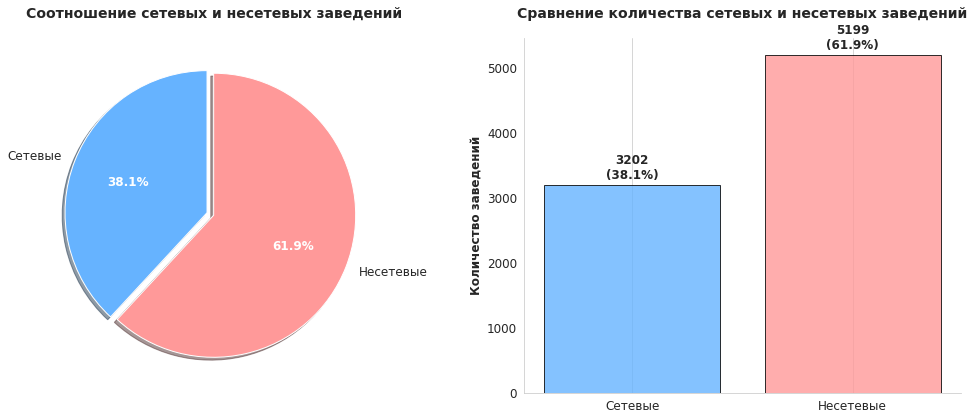

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#66b3ff', '#ff9999']
labels = ['Сетевые', 'Несетевые']
sizes = [chain_counts[True], chain_counts[False]]
explode = (0.05, 0)

wedges, texts, autotexts = axes[0].pie(sizes, explode=explode, labels=labels, 
                                        colors=colors, autopct='%1.1f%%',
                                        startangle=90, shadow=True)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

axes[0].set_title('Соотношение сетевых и несетевых заведений', 
                  fontsize=14, fontweight='bold', pad=20)

bars = axes[1].bar(labels, sizes, color=colors, edgecolor='black', alpha=0.8)

for bar, value, percent in zip(bars, sizes, [chain_percent[True], chain_percent[False]]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{value}\n({percent:.1f}%)', ha='center', va='bottom',
                 fontsize=12, fontweight='bold')

axes[1].set_ylabel('Количество заведений', fontsize=12, fontweight='bold')
axes[1].set_title('Сравнение количества сетевых и несетевых заведений', 
                  fontsize=14, fontweight='bold', pad=20)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [49]:
chain_by_category = df.groupby('category')['chain'].agg(['count', 'sum'])
chain_by_category['chain_percent'] = (chain_by_category['sum'] / chain_by_category['count'] * 100).round(1)
chain_by_category['non_chain_percent'] = 100 - chain_by_category['chain_percent']
chain_by_category = chain_by_category.sort_values('chain_percent', ascending=False)

print("\nДоля сетевых заведений по категориям:")
print(chain_by_category[['count', 'sum', 'chain_percent']])

max_chain_cat = chain_by_category.index[0]
min_chain_cat = chain_by_category.index[-1]

print(f"\nКатегория с наибольшей долей сетевых заведений: '{max_chain_cat}'")
print(f"   {chain_by_category.loc[max_chain_cat, 'sum']} из {chain_by_category.loc[max_chain_cat, 'count']} заведений ({chain_by_category.loc[max_chain_cat, 'chain_percent']}%)")

print(f"\nКатегория с наименьшей долей сетевых заведений: '{min_chain_cat}'")
print(f"   {chain_by_category.loc[min_chain_cat, 'sum']} из {chain_by_category.loc[min_chain_cat, 'count']} заведений ({chain_by_category.loc[min_chain_cat, 'chain_percent']}%)")


Доля сетевых заведений по категориям:
                 count  sum  chain_percent
category                                  
булочная           256  157           61.3
пиццерия           633  330           52.1
кофейня           1412  719           50.9
быстрое питание    603  232           38.5
ресторан          2042  729           35.7
кафе              2376  779           32.8
столовая           315   88           27.9
бар,паб            764  168           22.0

Категория с наибольшей долей сетевых заведений: 'булочная'
   157 из 256 заведений (61.3%)

Категория с наименьшей долей сетевых заведений: 'бар,паб'
   168 из 764 заведений (22.0%)


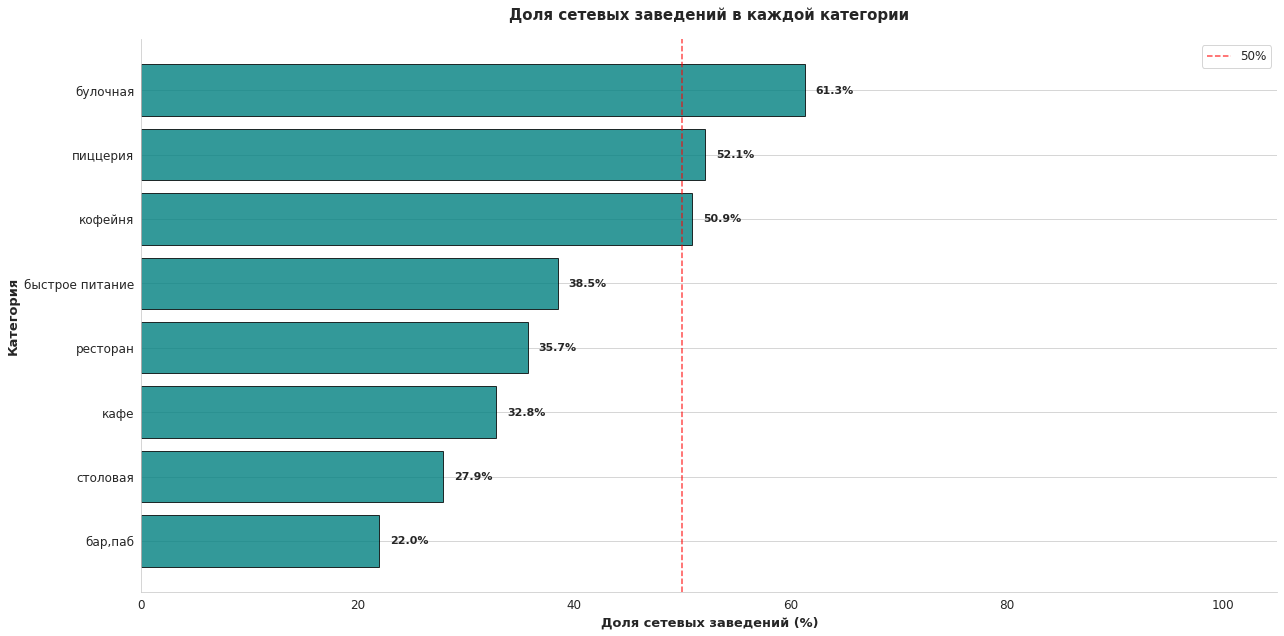

In [50]:
fig, ax = plt.subplots(figsize=(18, 9))

chain_sorted = chain_by_category.sort_values('chain_percent', ascending=True)

bars = ax.barh(chain_sorted.index, chain_sorted['chain_percent'], 
               color='teal', edgecolor='black', alpha=0.8)

for bar, value in zip(bars, chain_sorted['chain_percent']):
    ax.text(value + 1, bar.get_y() + bar.get_height()/2,
            f'{value}%', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Доля сетевых заведений (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Категория', fontsize=13, fontweight='bold')
ax.set_title('Доля сетевых заведений в каждой категории', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlim(0, 105)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50%')
ax.legend()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Несетевых (5199) заведений больше, чем сетевых (3202). 61.9% на 38.1% соответственно.

Чаще всего сетевыми являются булочные (61.3%), пиццерии (52.1%), кофейни (50.9%). В остальных типах заведений доля сетевых не такая большая.

---

### Количество посадочных мест


In [51]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (18, 9)

print(f"\nОбщая статистика по посадочным местам:")
print(f"  Всего заведений с данными: {df['seats'].notna().sum()}")
print(f"  Минимум: {df['seats'].min()}")
print(f"  Максимум: {df['seats'].max()}")
print(f"  Среднее: {df['seats'].mean():.1f}")
print(f"  Медиана: {df['seats'].median():.1f}")
print(f"  Стандартное отклонение: {df['seats'].std():.1f}")

q1 = df['seats'].quantile(0.25)
q3 = df['seats'].quantile(0.75)
iqr = q3 - q1
print(f"\nКвартили:")
print(f"  Q1 (25%): {q1:.0f}")
print(f"  Q3 (75%): {q3:.0f}")
print(f"  IQR: {iqr:.0f}")

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"\nГраницы для выбросов (метод IQR):")
print(f"  Нижняя граница: {lower_bound:.0f}")
print(f"  Верхняя граница: {upper_bound:.0f}")


Общая статистика по посадочным местам:
  Всего заведений с данными: 8401
  Минимум: 1
  Максимум: 1288
  Среднее: 94.5
  Медиана: 80.0
  Стандартное отклонение: 94.0

Квартили:
  Q1 (25%): 56
  Q3 (75%): 90
  IQR: 34

Границы для выбросов (метод IQR):
  Нижняя граница: 5
  Верхняя граница: 141


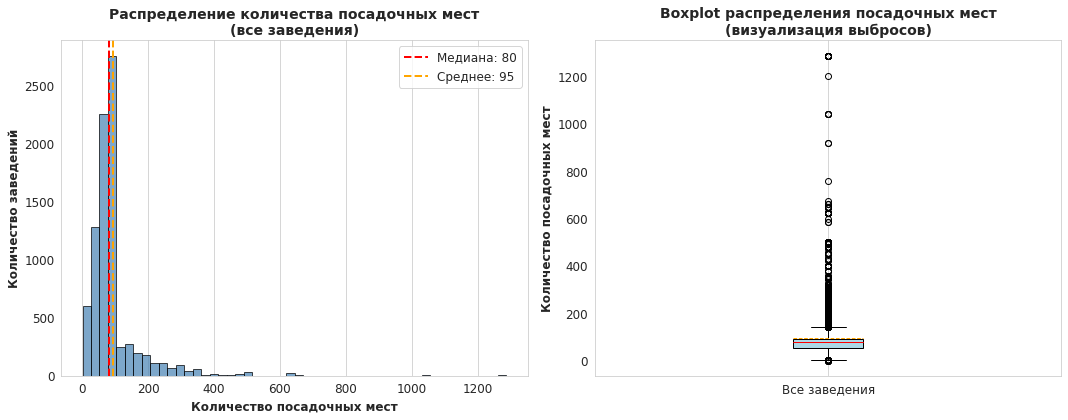

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hist(df['seats'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['seats'].median(), color='red', linestyle='--', linewidth=2, label=f'Медиана: {df["seats"].median():.0f}')
axes[0].axvline(df['seats'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Среднее: {df["seats"].mean():.0f}')
axes[0].set_xlabel('Количество посадочных мест', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Количество заведений', fontsize=12, fontweight='bold')
axes[0].set_title('Распределение количества посадочных мест\n(все заведения)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

boxplot_data = df['seats'].dropna()
bp = axes[1].boxplot(boxplot_data, vert=True, patch_artist=True,
                      showmeans=True, meanline=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['medians'][0].set_color('red')
bp['means'][0].set_color('orange')

axes[1].set_ylabel('Количество посадочных мест', fontsize=12, fontweight='bold')
axes[1].set_title('Boxplot распределения посадочных мест\n(визуализация выбросов)', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Все заведения'])
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [53]:
outliers = df[(df['seats'] > upper_bound) | (df['seats'] < lower_bound)]
outliers_high = df[df['seats'] > upper_bound]
outliers_low = df[df['seats'] < lower_bound]

print(f"\nНайдено выбросов: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% от всех заведений)")
print(f"  Выбросы вверх (очень много мест): {len(outliers_high)}")
print(f"  Выбросы вниз (очень мало мест): {len(outliers_low)}")

print("\nТоп-10 заведений с наибольшим количеством мест:")
top_seats = df.nlargest(10, 'seats')[['name', 'category', 'seats', 'district', 'chain']]
print(top_seats.to_string(index=False))

print("\nЗаведения с наименьшим количеством мест (не считая 0):")
bottom_seats = df[df['seats'] > 0].nsmallest(10, 'seats')[['name', 'category', 'seats', 'district', 'chain']]
print(bottom_seats.to_string(index=False))


Найдено выбросов: 1220 (14.52% от всех заведений)
  Выбросы вверх (очень много мест): 1163
  Выбросы вниз (очень мало мест): 57

Топ-10 заведений с наибольшим количеством мест:
             name category  seats                        district  chain
      delonixcafe ресторан   1288 Западный административный округ  False
        ян примус ресторан   1288 Западный административный округ   True
           мюнгер пиццерия   1288 Западный административный округ   True
 one price coffee  кофейня   1288 Западный административный округ   True
           гудбар  бар,паб   1288 Западный административный округ  False
           пивной  бар,паб   1288 Западный административный округ  False
   японская кухня ресторан   1288 Западный административный округ   True
            точка     кафе   1288 Западный административный округ   True
loftcafe академия     кафе   1288 Западный административный округ  False
     яндекс лавка ресторан   1288 Западный административный округ   True

Заведения с наимен

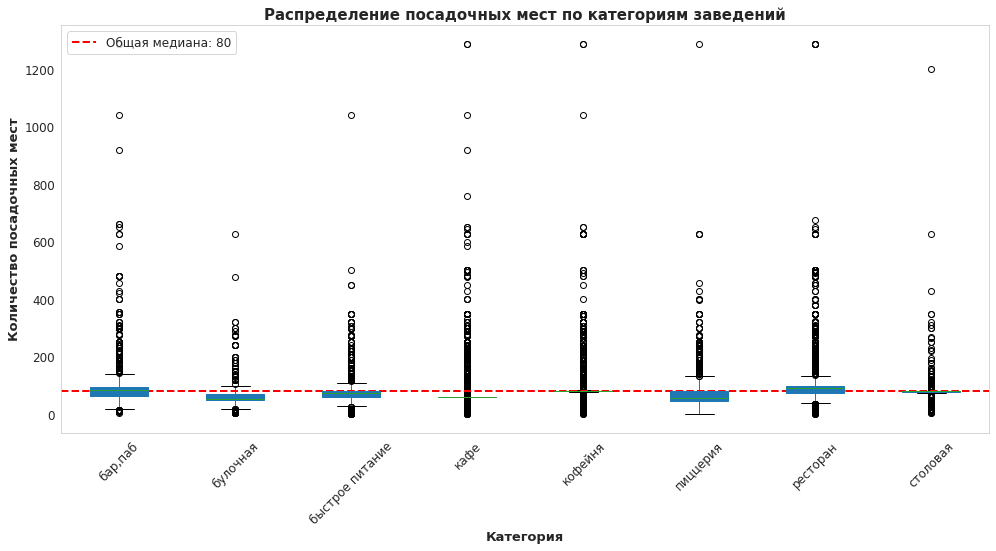

In [54]:
fig, ax = plt.subplots(figsize=(14, 8))

categories_order = df['category'].value_counts().index
df_boxplot = df[df['seats'].notna()]

bp_dict = df_boxplot.boxplot(column='seats', by='category', ax=ax, 
                              grid=False, patch_artist=True, rot=45)

ax.set_title('Распределение посадочных мест по категориям заведений', fontsize=15, fontweight='bold')
ax.set_xlabel('Категория', fontsize=13, fontweight='bold')
ax.set_ylabel('Количество посадочных мест', fontsize=13, fontweight='bold')
ax.axhline(y=df['seats'].median(), color='red', linestyle='--', 
           linewidth=2, label=f'Общая медиана: {df["seats"].median():.0f}')
ax.legend()

plt.suptitle('')
plt.tight_layout()
plt.show()

In [55]:
seats_by_category = df.groupby('category')['seats'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
seats_by_category = seats_by_category.sort_values('median', ascending=False)

print("\nНаиболее типичное значение - МЕДИАНА (устойчива к выбросам)")
print(seats_by_category.round(1).to_string())

for cat in seats_by_category.index:
    median_val = seats_by_category.loc[cat, 'median']
    mean_val = seats_by_category.loc[cat, 'mean']
    print(f"\n{cat}:")
    print(f"  Типичное количество мест: {median_val:.0f}")
    print(f"  Среднее: {mean_val:.0f}")
    if abs(mean_val - median_val) > median_val * 0.3:
        print(f"Есть сильные выбросы (среднее сильно отличается от медианы)")


Наиболее типичное значение - МЕДИАНА (устойчива к выбросам)
                 count   mean  median    std  min   max
category                                               
ресторан          2042  110.7      90   98.2    2  1288
бар,паб            764  109.2      84  114.9    6  1288
кофейня           1412   98.0      80   93.7    2  1288
столовая           315   91.6      80   88.4    4  1200
быстрое питание    603   91.1      75   80.5    1  1040
кафе              2376   80.2      60   85.8    1  1288
пиццерия           633   82.9      56   93.4    1  1288
булочная           256   75.8      52   75.0    3   625

ресторан:
  Типичное количество мест: 90
  Среднее: 111

бар,паб:
  Типичное количество мест: 84
  Среднее: 109

кофейня:
  Типичное количество мест: 80
  Среднее: 98

столовая:
  Типичное количество мест: 80
  Среднее: 92

быстрое питание:
  Типичное количество мест: 75
  Среднее: 91

кафе:
  Типичное количество мест: 60
  Среднее: 80
Есть сильные выбросы (среднее сильно отл

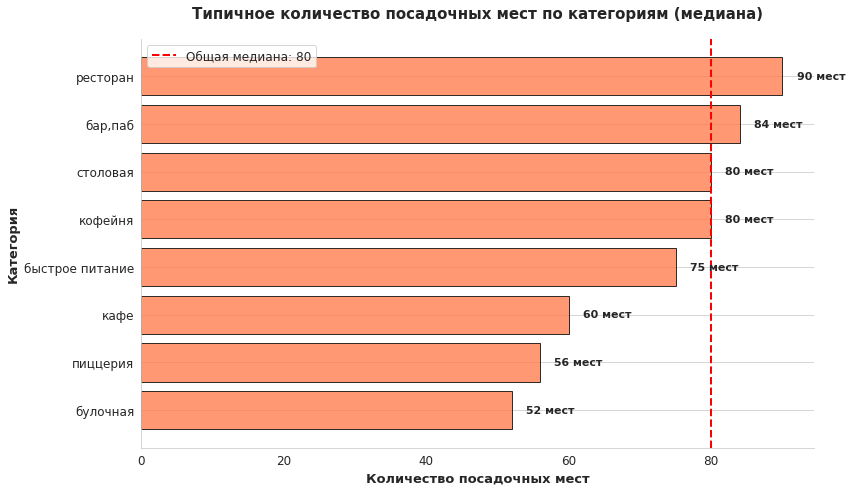

In [56]:
fig, ax = plt.subplots(figsize=(12, 7))

seats_sorted = seats_by_category.sort_values('median', ascending=True)

bars = ax.barh(seats_sorted.index, seats_sorted['median'], 
               color='coral', edgecolor='black', alpha=0.8)

for bar, median_val in zip(bars, seats_sorted['median']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{median_val:.0f} мест', va='center', fontsize=11, fontweight='bold')

ax.axvline(x=df['seats'].median(), color='red', linestyle='--', 
           linewidth=2, label=f'Общая медиана: {df["seats"].median():.0f}')

ax.set_xlabel('Количество посадочных мест', fontsize=13, fontweight='bold')
ax.set_ylabel('Категория', fontsize=13, fontweight='bold')
ax.set_title('Типичное количество посадочных мест по категориям (медиана)',
             fontsize=15, fontweight='bold', pad=20)
ax.legend()
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

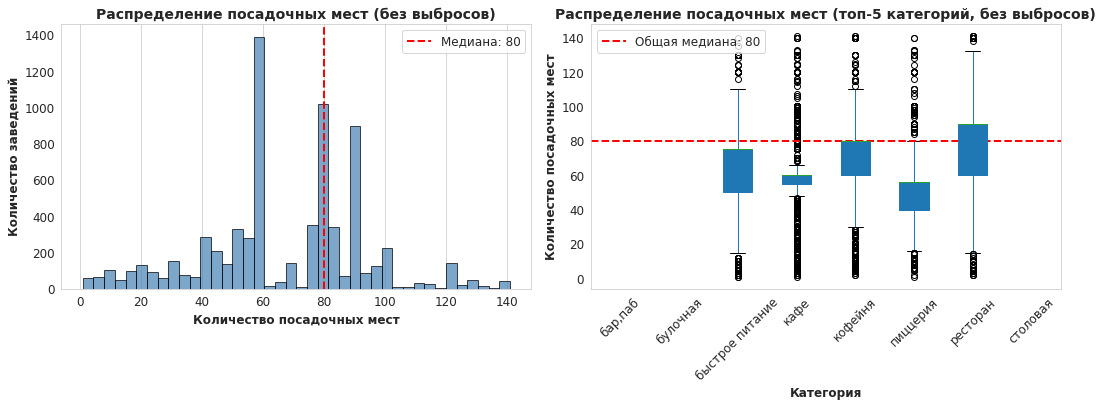

In [57]:
seats_limited = df[df['seats'] <= upper_bound]['seats'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hist(seats_limited, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['seats'].median(), color='red', linestyle='--', linewidth=2, 
                label=f'Медиана: {df["seats"].median():.0f}')
axes[0].set_xlabel('Количество посадочных мест', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Количество заведений', fontsize=12, fontweight='bold')
axes[0].set_title('Распределение посадочных мест (без выбросов)', 
                  fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

categories_small = ['кафе', 'ресторан', 'кофейня', 'пиццерия', 'быстрое питание']
df_filtered = df[df['category'].isin(categories_small) & (df['seats'] <= upper_bound)]

bp_dict = df_filtered.boxplot(column='seats', by='category', ax=axes[1],
                               grid=False, patch_artist=True, rot=45)

axes[1].set_title('Распределение посадочных мест (топ-5 категорий, без выбросов)', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Категория', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Количество посадочных мест', fontsize=12, fontweight='bold')
axes[1].axhline(y=df['seats'].median(), color='red', linestyle='--', 
                linewidth=2, label=f'Общая медиана: {df["seats"].median():.0f}')
axes[1].legend()

plt.suptitle('')
plt.tight_layout()
plt.show()

В данных и вправду встречались аномальные значения посадочных мест. Во многих категориях максимально зафиксировано аж 1288 места, наверняка техническая ошибка или кто-то подсчитал каждый стул в здании (ТЦ, например). В то же время есть и крайне малые значения в каждой категории, опять же возможны технические ошибки, либо мест и вправду толком нет или мало (уличная еда или что-то подобное). 
Общая медиана получилась равно 80 мест.

В каждой категории следующее типичное количество мест:

ресторан - 90

бар,паб - 84

кофейня - 80

столовая - 80
  
быстрое питание - 75

булочная - 52

кафе - 60

пиццерия - 56

---

### Рейтинг заведений

In [58]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (18, 9)

print(f"\nОбщая статистика по рейтингам:")
print(f"  Минимальный рейтинг: {df['rating'].min()}")
print(f"  Максимальный рейтинг: {df['rating'].max()}")
print(f"  Средний рейтинг: {df['rating'].mean():.2f}")
print(f"  Медианный рейтинг: {df['rating'].median():.2f}")
print(f"  Стандартное отклонение: {df['rating'].std():.2f}")

rating_by_category = df.groupby('category')['rating'].agg(['mean', 'median', 'std', 'count', 'min', 'max'])
rating_by_category = rating_by_category.sort_values('mean', ascending=False)

print(rating_by_category.round(2).to_string())


Общая статистика по рейтингам:
  Минимальный рейтинг: 1.0
  Максимальный рейтинг: 5.0
  Средний рейтинг: 4.23
  Медианный рейтинг: 4.30
  Стандартное отклонение: 0.47
                 mean  median   std  count  min  max
category                                            
бар,паб          4.39     4.4  0.38    764  1.1  5.0
пиццерия         4.30     4.3  0.34    633  1.0  5.0
ресторан         4.29     4.3  0.41   2042  1.0  5.0
кофейня          4.28     4.3  0.37   1412  1.4  5.0
булочная         4.27     4.3  0.39    256  1.3  5.0
столовая         4.21     4.3  0.45    315  1.0  5.0
кафе             4.12     4.2  0.57   2376  1.0  5.0
быстрое питание  4.05     4.2  0.56    603  1.1  5.0


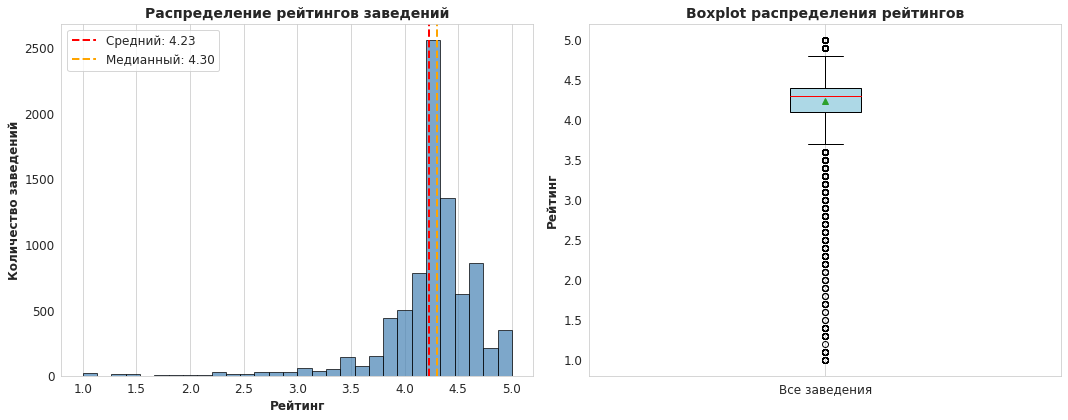

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hist(df['rating'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['rating'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Средний: {df["rating"].mean():.2f}')
axes[0].axvline(df['rating'].median(), color='orange', linestyle='--', linewidth=2, 
                label=f'Медианный: {df["rating"].median():.2f}')
axes[0].set_xlabel('Рейтинг', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Количество заведений', fontsize=12, fontweight='bold')
axes[0].set_title('Распределение рейтингов заведений', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

bp = axes[1].boxplot(df['rating'], vert=True, patch_artist=True, showmeans=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['medians'][0].set_color('red')
bp['means'][0].set_color('orange')
axes[1].set_ylabel('Рейтинг', fontsize=12, fontweight='bold')
axes[1].set_title('Boxplot распределения рейтингов', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Все заведения'])
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

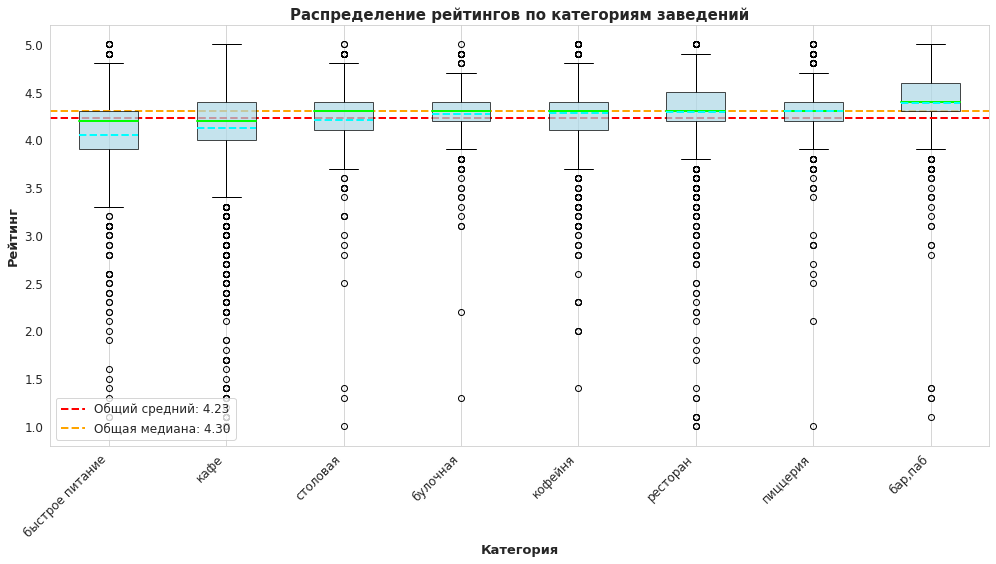

In [60]:
fig, ax = plt.subplots(figsize=(14, 8))

categories_sorted = rating_by_category.sort_values('mean', ascending=True).index

boxplot_data = [df[df['category'] == cat]['rating'].dropna() for cat in categories_sorted]

bp = ax.boxplot(boxplot_data, labels=categories_sorted, patch_artist=True, 
                showmeans=True, meanline=True, vert=True)

for box in bp['boxes']:
    box.set_facecolor('lightblue')
    box.set_alpha(0.7)

for median in bp['medians']:
    median.set_color('lime')
    median.set_linewidth(2)

for mean in bp['means']:
    mean.set_color('cyan')
    mean.set_linewidth(2)

ax.axhline(y=df['rating'].mean(), color='red', linestyle='--', 
           linewidth=2, label=f'Общий средний: {df["rating"].mean():.2f}')
ax.axhline(y=df['rating'].median(), color='orange', linestyle='--', 
           linewidth=2, label=f'Общая медиана: {df["rating"].median():.2f}')

ax.set_xticklabels(categories_sorted, rotation=45, ha='right')

ax.set_title('Распределение рейтингов по категориям заведений', 
             fontsize=15, fontweight='bold')
ax.set_xlabel('Категория', fontsize=13, fontweight='bold')
ax.set_ylabel('Рейтинг', fontsize=13, fontweight='bold')
ax.legend(loc='lower left')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

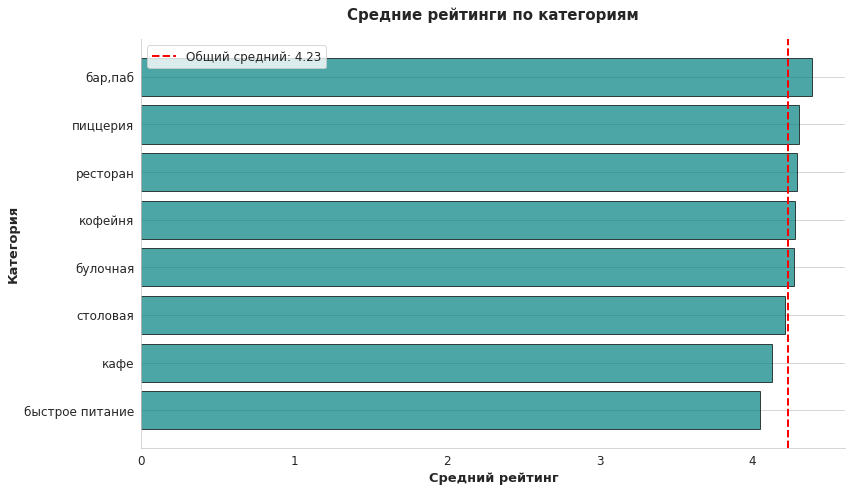

In [61]:
fig, ax = plt.subplots(figsize=(12, 7))

rating_sorted = rating_by_category.sort_values('mean', ascending=True)

bars = ax.barh(rating_sorted.index, rating_sorted['mean'], 
               capsize=3,
               color='teal', edgecolor='black', alpha=0.7, error_kw={'elinewidth': 2})

ax.axvline(x=df['rating'].mean(), color='red', linestyle='--', 
           linewidth=2, label=f'Общий средний: {df["rating"].mean():.2f}')

ax.set_xlabel('Средний рейтинг', fontsize=13, fontweight='bold')
ax.set_ylabel('Категория', fontsize=13, fontweight='bold')
ax.set_title('Средние рейтинги по категориям', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend()
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

В среднем рейтинги всех типов заведений не сильно отличаются друг от друга и близки к общему среднему значению 4.23. Бары/пабы, пиццерии и рестораны имеют рейтинги повыше, а кафе и особенно быстрое питание отстают.

---

### Корреляция с рейтингом заведений

In [63]:
sns.set_style('whitegrid')

features_for_phik = [
    'rating',
    'category',
    'district',
    'chain',
    'seats',
    'price',
    'is_24_7'
]

df_task6 = df[features_for_phik].copy()

df_task6['rating'] = pd.to_numeric(df_task6['rating'], errors='coerce')
df_task6['seats'] = pd.to_numeric(df_task6['seats'], errors='coerce')

df_task6 = df_task6.dropna(subset=['rating'])

cat_columns = ['category', 'district', 'price']



for col in cat_columns:
    df_task6[col] = df_task6[col].cat.add_categories(['не указано'])
    df_task6[col] = df_task6[col].fillna('не указано').astype(str)

df_task6['chain'] = df_task6['chain'].fillna(False).astype(str)
df_task6['is_24_7'] = df_task6['is_24_7'].fillna(False).astype(str)

display(df_task6.head())
print(df_task6.info())

,rating,category,district,chain,seats,price,is_24_7
0,5.0,кафе,Северный административный округ,False,60,не указано,False
1,4.5,ресторан,Северный административный округ,False,4,выше среднего,False
2,4.6,кафе,Северный административный округ,False,45,средние,False
3,5.0,кофейня,Северный административный округ,False,80,не указано,False
4,5.0,пиццерия,Северный административный округ,True,148,средние,False


<class 'pandas.core.frame.DataFrame'>
Int64Index: 8401 entries, 0 to 8405
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rating    8401 non-null   float64
 1   category  8401 non-null   object 
 2   district  8401 non-null   object 
 3   chain     8401 non-null   object 
 4   seats     8401 non-null   int64  
 5   price     8401 non-null   object 
 6   is_24_7   8401 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 525.1+ KB
None


In [64]:
phik_matrix = df_task6.phik_matrix(
    interval_cols=['rating', 'seats']
)

display(phik_matrix)

,rating,category,district,chain,seats,price,is_24_7
rating,1.000000,0.190020,0.200918,0.108055,0.000000,0.281083,0.150762
category,0.190020,1.000000,0.174487,0.265786,0.059871,0.329689,0.244785
district,0.200918,0.174487,1.000000,0.064461,0.274884,0.203028,0.076344
chain,0.108055,0.265786,0.064461,1.000000,0.057607,0.088785,0.043571
seats,0.000000,0.059871,0.274884,0.057607,1.000000,0.043799,0.032258
price,0.281083,0.329689,0.203028,0.088785,0.043799,1.000000,0.063727
is_24_7,0.150762,0.244785,0.076344,0.043571,0.032258,0.063727,1.000000


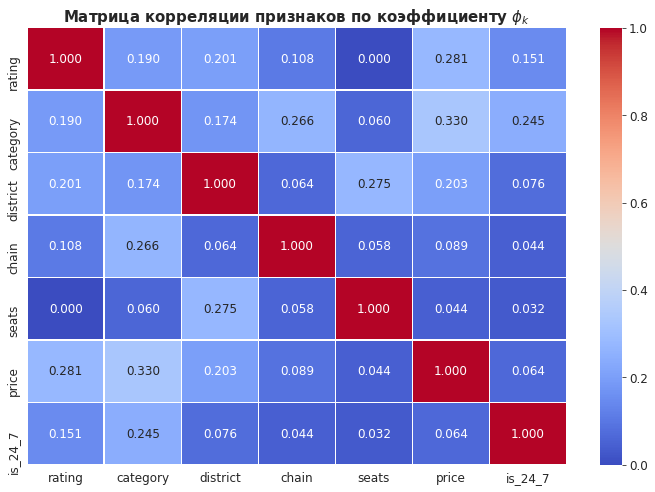

In [65]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    phik_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Матрица корреляции признаков по коэффициенту $\\phi_k$',
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [66]:
rating_phik = (
    phik_matrix['rating']
    .drop('rating')
    .sort_values(ascending=False)
    .reset_index()
)

rating_phik.columns = ['feature', 'phik_correlation']

display(rating_phik)

,feature,phik_correlation
0,price,0.281083
1,district,0.200918
2,category,0.190020
3,is_24_7,0.150762
4,chain,0.108055
5,seats,0.000000


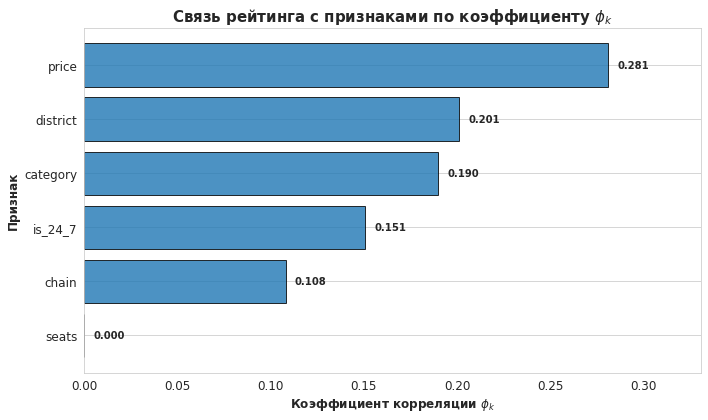

In [67]:
plt.figure(figsize=(10, 6))

plot_data = rating_phik.sort_values('phik_correlation', ascending=True)

bars = plt.barh(
    plot_data['feature'],
    plot_data['phik_correlation'],
    edgecolor='black',
    alpha=0.8
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.3f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Связь рейтинга с признаками по коэффициенту $\\phi_k$',
          fontsize=15, fontweight='bold')
plt.xlabel('Коэффициент корреляции $\\phi_k$', fontsize=12, fontweight='bold')
plt.ylabel('Признак', fontsize=12, fontweight='bold')
plt.xlim(0, rating_phik['phik_correlation'].max() + 0.05)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [68]:
strongest_feature = rating_phik.loc[0, 'feature']
strongest_phik = rating_phik.loc[0, 'phik_correlation']

print('Самая сильная связь с рейтингом по результатам phik_matrix():')
print(f'Признак: {strongest_feature}')
print(f'Коэффициент phi_k: {strongest_phik:.3f}')

Самая сильная связь с рейтингом по результатам phik_matrix():
Признак: price
Коэффициент phi_k: 0.281


Наиболее заметная связь с рейтингом наблюдается у признака "price". Коэффициент phi_k для него составляет 0.281. Категория заведения, административный округ, сетевой статус, количество посадочных мест, ценовая категория и круглосуточный режим могут быть связаны с рейтингом, однако сила этой связи в большинстве случаев невелика.

In [70]:
strongest_feature_stats = (
    df_task6
    .groupby(strongest_feature)
    .agg(
        places_count=('rating', 'count'),
        mean_rating=('rating', 'mean'),
        median_rating=('rating', 'median')
    )
    .sort_values('mean_rating', ascending=False)
    .reset_index()
)

strongest_feature_stats['mean_rating'] = strongest_feature_stats['mean_rating'].round(2)
strongest_feature_stats['median_rating'] = strongest_feature_stats['median_rating'].round(2)

display(strongest_feature_stats)

,price,places_count,mean_rating,median_rating
0,высокие,478,4.44,4.4
1,выше среднего,564,4.39,4.4
2,средние,2117,4.30,4.3
3,низкие,156,4.17,4.2
4,не указано,5086,4.17,4.3


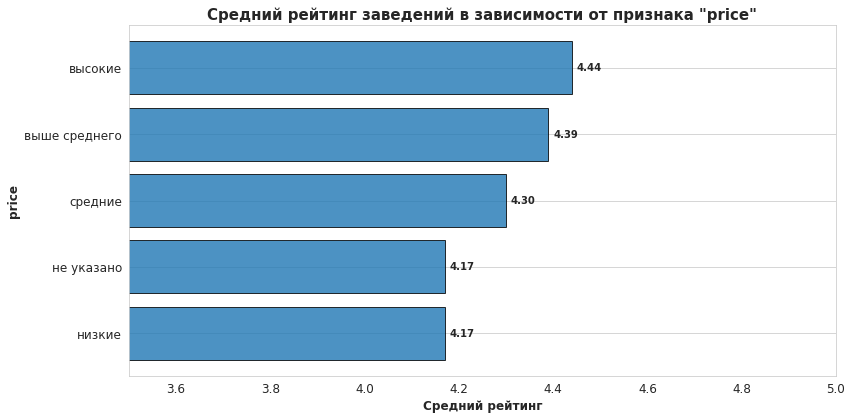

In [71]:
plt.figure(figsize=(12, 6))

plot_data = strongest_feature_stats.sort_values('mean_rating', ascending=True)

bars = plt.barh(
    plot_data[strongest_feature].astype(str),
    plot_data['mean_rating'],
    edgecolor='black',
    alpha=0.8
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.2f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(f'Средний рейтинг заведений в зависимости от признака "{strongest_feature}"',
          fontsize=15, fontweight='bold')
plt.xlabel('Средний рейтинг', fontsize=12, fontweight='bold')
plt.ylabel(strongest_feature, fontsize=12, fontweight='bold')
plt.xlim(3.5, 5.0)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

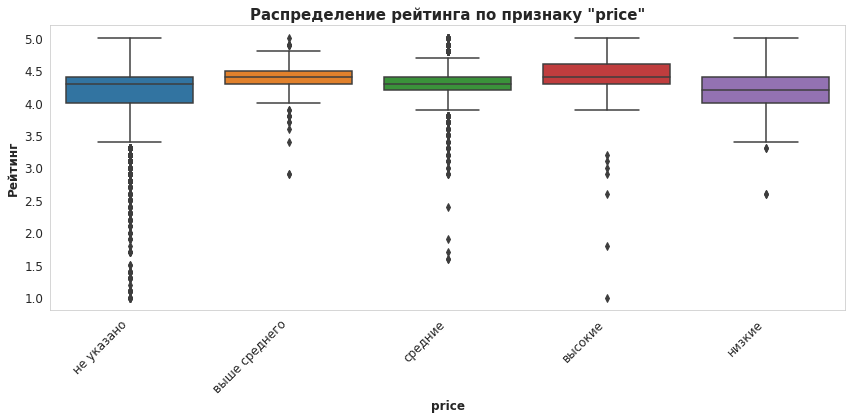

In [72]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_task6,
    x=strongest_feature,
    y='rating'
)

plt.title(f'Распределение рейтинга по признаку "{strongest_feature}"',
          fontsize=15, fontweight='bold')
plt.xlabel(strongest_feature, fontsize=12, fontweight='bold')
plt.ylabel('Рейтинг', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Наибольшее влияние на рейтинг оказывают тип заведения, округ и особенно ценовая категория. Заведения с ценами выше среднего и высокими соответственно имеют выше рейтинг. Дополнительная проверка через группировку по признаку price показала, что средний рейтинг действительно отличается между группами. Но вероятно, что пользовательская оценка формируется под влиянием совокупности факторов: категории заведения, ценового сегмента, качества обслуживания, расположения, формата заведения и ожиданий посетителей.

---

### Топ-15 популярных сетей в Москве

In [73]:
sns.set_style("whitegrid")


def clean_name(name):
    name = str(name).lower().strip()
    name = name.replace('ё', 'е')
    name = re.sub(r'[«»"“”]', '', name)
    name = re.sub(r'\s+', ' ', name)
    return name


def get_mode(series):
    mode = series.mode()
    if len(mode) > 0:
        return mode.iloc[0]
    return np.nan


def get_unique_values(series):
    values = sorted(series.dropna().astype(str).unique())
    return ', '.join(values)


df_task7 = df.copy()

df_task7['name_clean'] = df_task7['name'].apply(clean_name)

chains = df_task7[df_task7['chain'] == 1].copy()

print(f'Всего сетевых заведений в данных: {len(chains)}')
print(f'Количество уникальных сетей: {chains["name_clean"].nunique()}')

Всего сетевых заведений в данных: 3202
Количество уникальных сетей: 745


In [74]:
top_15_chains = (
    chains
    .groupby('name_clean')
    .agg(
        chain_name=('name', get_mode),
        places_count=('name', 'count'),
        mean_rating=('rating', 'mean'),
        median_rating=('rating', 'median'),
        main_category=('category', get_mode),
        categories=('category', get_unique_values),
        districts_count=('district', 'nunique')
    )
    .sort_values('places_count', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

top_15_chains['mean_rating'] = top_15_chains['mean_rating'].round(2)
top_15_chains['median_rating'] = top_15_chains['median_rating'].round(2)

display(top_15_chains)

,chain_name,places_count,mean_rating,median_rating,main_category,categories,districts_count
0,шоколадница,120,4.18,4.20,кофейня,"кафе, кофейня",9
1,доминос пицца,76,4.17,4.20,пиццерия,пиццерия,9
2,додо пицца,74,4.29,4.30,пиццерия,пиццерия,9
3,one price coffee,71,4.06,4.20,кофейня,кофейня,9
4,яндекс лавка,69,3.87,4.00,ресторан,ресторан,9
5,cofix,65,4.08,4.10,кофейня,кофейня,9
6,prime,50,4.12,4.20,ресторан,"кафе, ресторан",8
7,хинкальная,44,4.32,4.40,кафе,"бар,паб, быстрое питание, кафе, ресторан, стол...",9
8,кофепорт,42,4.15,4.20,кофейня,кофейня,8
9,кулинарная лавка братьев караваевых,39,4.39,4.40,кафе,кафе,6


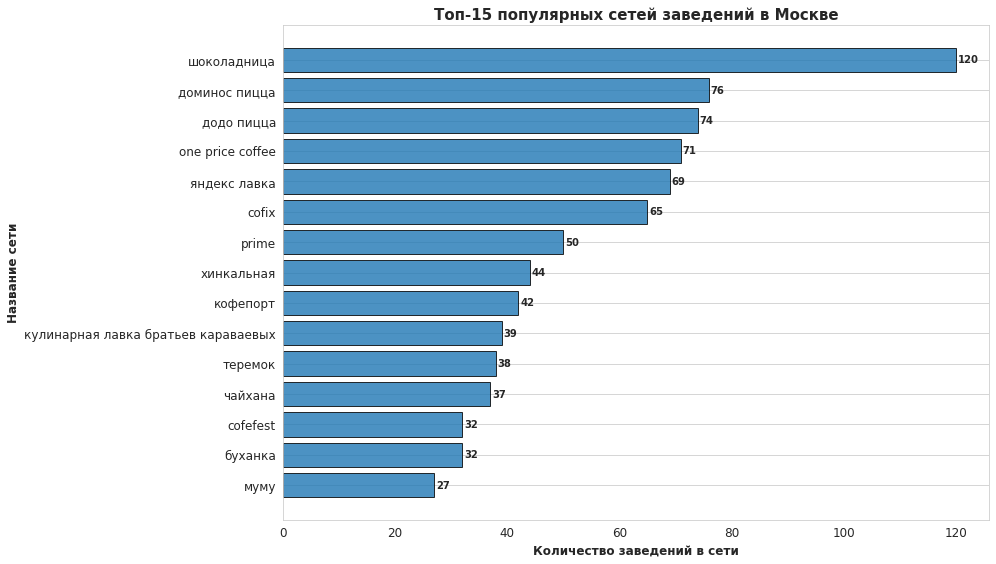

In [75]:
plt.figure(figsize=(14, 8))

top_15_sorted = top_15_chains.sort_values('places_count', ascending=True)

bars = plt.barh(
    top_15_sorted['chain_name'],
    top_15_sorted['places_count'],
    edgecolor='black',
    alpha=0.8
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Топ-15 популярных сетей заведений в Москве', fontsize=15, fontweight='bold')
plt.xlabel('Количество заведений в сети', fontsize=12, fontweight='bold')
plt.ylabel('Название сети', fontsize=12, fontweight='bold')
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

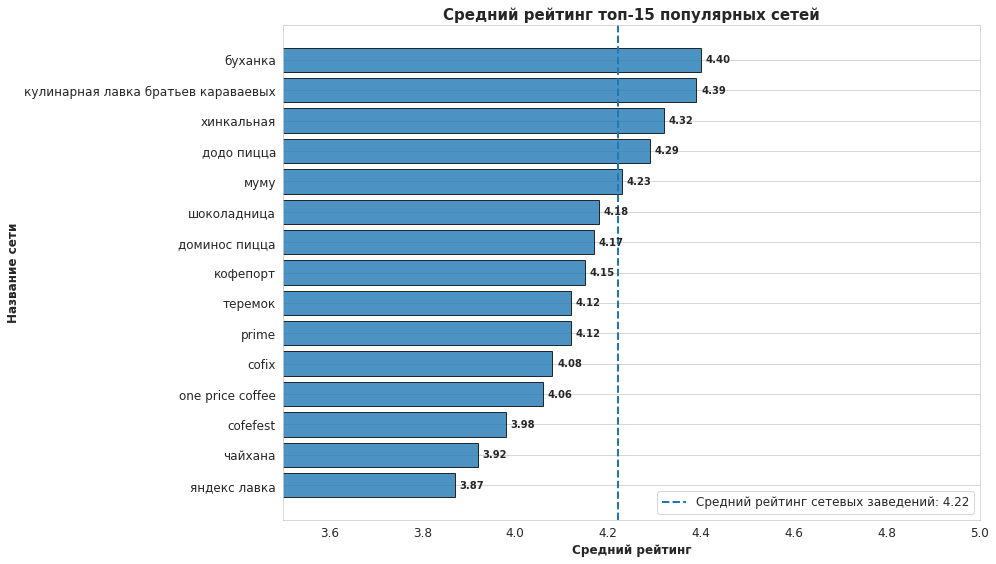

In [76]:
plt.figure(figsize=(14, 8))

rating_sorted = top_15_chains.sort_values('mean_rating', ascending=True)

bars = plt.barh(
    rating_sorted['chain_name'],
    rating_sorted['mean_rating'],
    edgecolor='black',
    alpha=0.8
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.2f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.axvline(
    x=chains['rating'].mean(),
    linestyle='--',
    linewidth=2,
    label=f'Средний рейтинг сетевых заведений: {chains["rating"].mean():.2f}'
)

plt.title('Средний рейтинг топ-15 популярных сетей', fontsize=15, fontweight='bold')
plt.xlabel('Средний рейтинг', fontsize=12, fontweight='bold')
plt.ylabel('Название сети', fontsize=12, fontweight='bold')
plt.xlim(3.5, 5.0)
plt.legend()
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

,category,chains_count
0,кофейня,5
1,кафе,4
2,ресторан,3
3,пиццерия,2
4,булочная,1


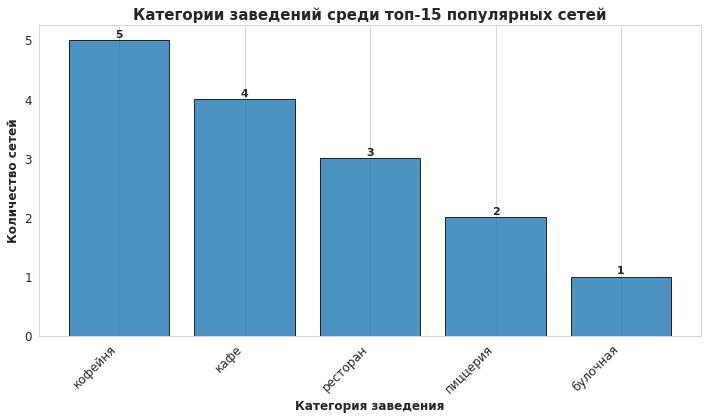

In [77]:
category_counts_top15 = (
    top_15_chains['main_category']
    .value_counts()
    .reset_index()
)

category_counts_top15.columns = ['category', 'chains_count']

display(category_counts_top15)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    category_counts_top15['category'],
    category_counts_top15['chains_count'],
    edgecolor='black',
    alpha=0.8
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f'{int(height)}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title('Категории заведений среди топ-15 популярных сетей', fontsize=15, fontweight='bold')
plt.xlabel('Категория заведения', fontsize=12, fontweight='bold')
plt.ylabel('Количество сетей', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

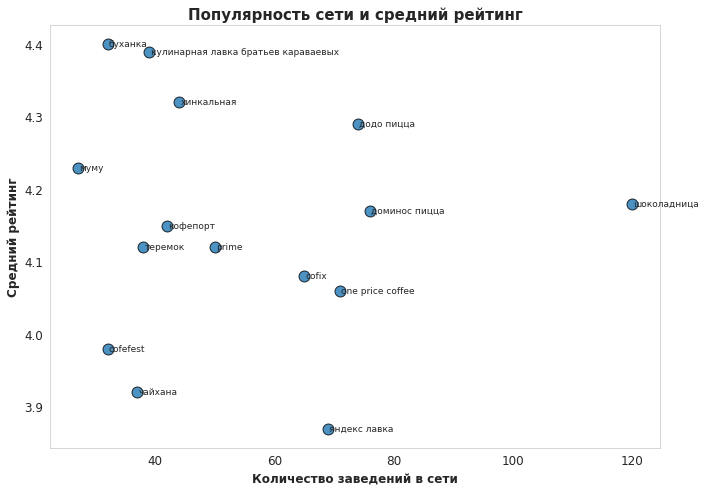

In [78]:
plt.figure(figsize=(10, 7))

plt.scatter(
    top_15_chains['places_count'],
    top_15_chains['mean_rating'],
    s=120,
    alpha=0.8,
    edgecolor='black'
)

for _, row in top_15_chains.iterrows():
    plt.text(
        row['places_count'] + 0.2,
        row['mean_rating'],
        row['chain_name'],
        fontsize=9,
        va='center'
    )

plt.title('Популярность сети и средний рейтинг', fontsize=15, fontweight='bold')
plt.xlabel('Количество заведений в сети', fontsize=12, fontweight='bold')
plt.ylabel('Средний рейтинг', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Самой популярной сетью в Москве является "шоколадница" с количеством заведений 120. Средний рейтинг 4.18.
Среди топ-15 популярных сетей чаще всего встречаются следующие категории заведений: кофейня - 5, кафе - 4, ресторан - 3, пиццерия - 2, булочная - 1.

Популярность сети не обязательно означает самый высокий рейтинг: часть крупных сетей имеет средние оценки, близкие к общему уровню сетевых заведений. Поэтому количество заведений скорее отражает распространение сети, а не преимущество по оценкам пользователей.

---

### Вариация среднего чека


In [79]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

df_task8 = df.copy()

df_task8 = df_task8[
    df_task8['middle_avg_bill'].notna() &
    df_task8['district'].notna()
].copy()

df_task8['middle_avg_bill'] = pd.to_numeric(df_task8['middle_avg_bill'], errors='coerce')

df_task8 = df_task8[df_task8['middle_avg_bill'] > 0].copy()

print(f'Количество заведений для анализа: {len(df_task8)}')
print(f'Количество административных округов: {df_task8["district"].nunique()}')

display(df_task8[['name', 'category', 'district', 'middle_avg_bill']].head())

Количество заведений для анализа: 3148
Количество административных округов: 9


,name,category,district,middle_avg_bill
1,четыре комнаты,ресторан,Северный административный округ,1550.0
2,хазри,кафе,Северный административный округ,1000.0
4,иль марко,пиццерия,Северный административный округ,500.0
6,огни города,"бар,паб",Северный административный округ,199.0
7,mr уголёк,быстрое питание,Северный административный округ,250.0


In [80]:
district_bill_stats = (
    df_task8
    .groupby('district')
    .agg(
        places_count=('middle_avg_bill', 'count'),
        mean_bill=('middle_avg_bill', 'mean'),
        median_bill=('middle_avg_bill', 'median'),
        std_bill=('middle_avg_bill', 'std'),
        min_bill=('middle_avg_bill', 'min'),
        max_bill=('middle_avg_bill', 'max')
    )
    .sort_values('median_bill', ascending=False)
    .reset_index()
)

district_bill_stats['mean_bill'] = district_bill_stats['mean_bill'].round(0).astype(int)
district_bill_stats['median_bill'] = district_bill_stats['median_bill'].round(0).astype(int)
district_bill_stats['std_bill'] = district_bill_stats['std_bill'].round(0)
district_bill_stats['min_bill'] = district_bill_stats['min_bill'].round(0).astype(int)
district_bill_stats['max_bill'] = district_bill_stats['max_bill'].round(0).astype(int)

display(district_bill_stats)

,district,places_count,mean_bill,median_bill,std_bill,min_bill,max_bill
0,Западный административный округ,306,1053,1000,779.0,50,5250
1,Центральный административный округ,1059,1192,1000,920.0,67,7250
2,Северо-Западный административный округ,157,822,700,595.0,120,2900
3,Северный административный округ,322,928,650,913.0,130,11000
4,Юго-Западный административный округ,235,793,600,559.0,100,2750
5,Восточный административный округ,260,821,575,851.0,50,10000
6,Северо-Восточный административный округ,301,717,500,591.0,50,4500
7,Южный административный округ,314,834,500,2009.0,100,35000
8,Юго-Восточный административный округ,194,654,450,567.0,30,3750


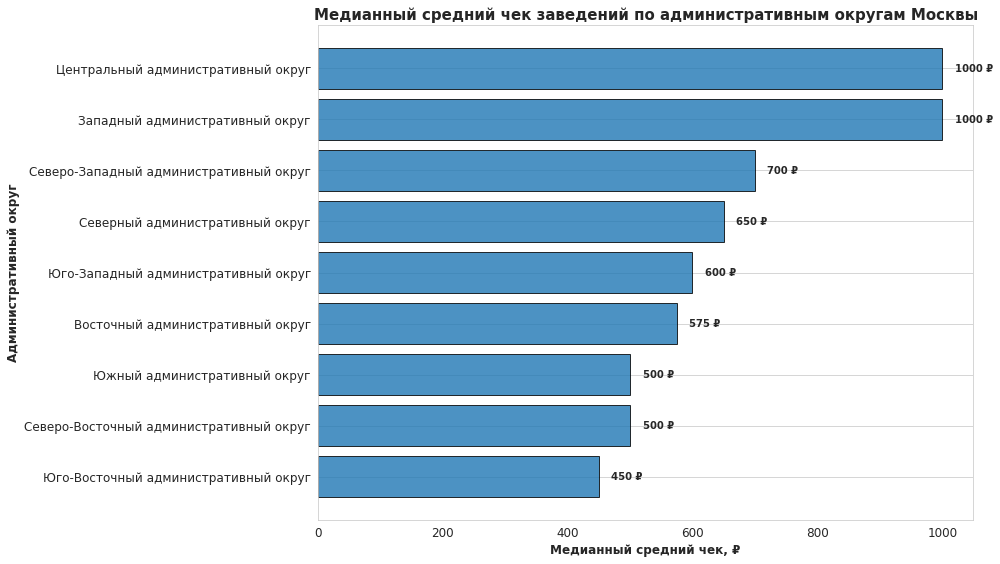

In [81]:
plt.figure(figsize=(14, 8))

plot_data = district_bill_stats.sort_values('median_bill', ascending=True)

bars = plt.barh(
    plot_data['district'],
    plot_data['median_bill'],
    edgecolor='black',
    alpha=0.8
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 20,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)} ₽',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Медианный средний чек заведений по административным округам Москвы',
          fontsize=15, fontweight='bold')
plt.xlabel('Медианный средний чек, ₽', fontsize=12, fontweight='bold')
plt.ylabel('Административный округ', fontsize=12, fontweight='bold')
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [82]:
df_task8['center_group'] = np.where(
    df_task8['district'] == 'Центральный административный округ',
    'ЦАО',
    'Другие округа'
)

center_comparison = (
    df_task8
    .groupby('center_group')
    .agg(
        places_count=('middle_avg_bill', 'count'),
        mean_bill=('middle_avg_bill', 'mean'),
        median_bill=('middle_avg_bill', 'median'),
        std_bill=('middle_avg_bill', 'std'),
        min_bill=('middle_avg_bill', 'min'),
        max_bill=('middle_avg_bill', 'max')
    )
    .reset_index()
)

center_comparison['mean_bill'] = center_comparison['mean_bill'].round(0).astype(int)
center_comparison['median_bill'] = center_comparison['median_bill'].round(0).astype(int)
center_comparison['std_bill'] = center_comparison['std_bill'].round(0)

display(center_comparison)

,center_group,places_count,mean_bill,median_bill,std_bill,min_bill,max_bill
0,Другие округа,2089,840,600,1033.0,30.0,35000.0
1,ЦАО,1059,1192,1000,920.0,67.0,7250.0


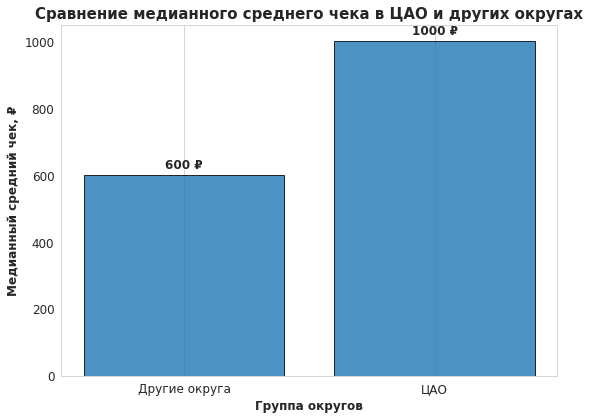

In [83]:
plt.figure(figsize=(8, 6))

bars = plt.bar(
    center_comparison['center_group'],
    center_comparison['median_bill'],
    edgecolor='black',
    alpha=0.8
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 20,
        f'{int(height)} ₽',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.title('Сравнение медианного среднего чека в ЦАО и других округах',
          fontsize=15, fontweight='bold')
plt.xlabel('Группа округов', fontsize=12, fontweight='bold')
plt.ylabel('Медианный средний чек, ₽', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

---


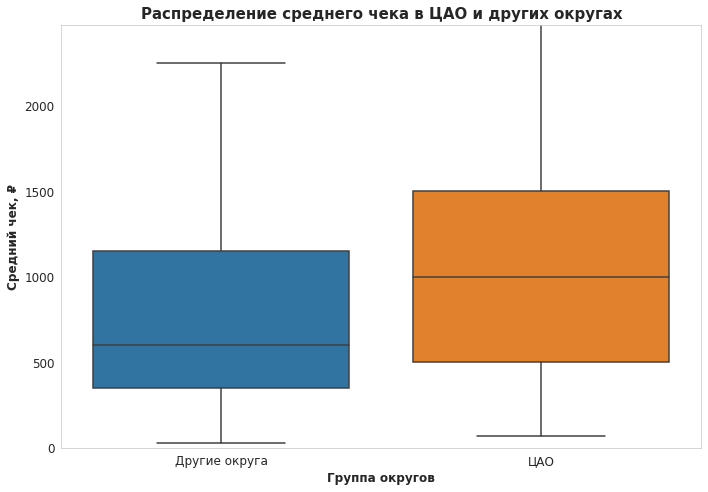

In [84]:
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=df_task8,
    x='center_group',
    y='middle_avg_bill'
)

plt.title('Распределение среднего чека в ЦАО и других округах',
          fontsize=15, fontweight='bold')
plt.xlabel('Группа округов', fontsize=12, fontweight='bold')
plt.ylabel('Средний чек, ₽', fontsize=12, fontweight='bold')

plt.ylim(0, df_task8['middle_avg_bill'].quantile(0.95) * 1.1)

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [85]:
def get_distance_group(district):
    if district == 'Центральный административный округ':
        return '1. Центр'
    else:
        return '2. Нецентральные округа'


df_task8['distance_group'] = df_task8['district'].apply(get_distance_group)

distance_stats = (
    df_task8
    .groupby('distance_group')
    .agg(
        places_count=('middle_avg_bill', 'count'),
        mean_bill=('middle_avg_bill', 'mean'),
        median_bill=('middle_avg_bill', 'median'),
        std_bill=('middle_avg_bill', 'std')
    )
    .reset_index()
    .sort_values('distance_group')
)

distance_stats['mean_bill'] = distance_stats['mean_bill'].round(0).astype(int)
distance_stats['median_bill'] = distance_stats['median_bill'].round(0).astype(int)
distance_stats['std_bill'] = distance_stats['std_bill'].round(0)

display(distance_stats)

,distance_group,places_count,mean_bill,median_bill,std_bill
0,1. Центр,1059,1192,1000,920.0
1,2. Нецентральные округа,2089,840,600,1033.0


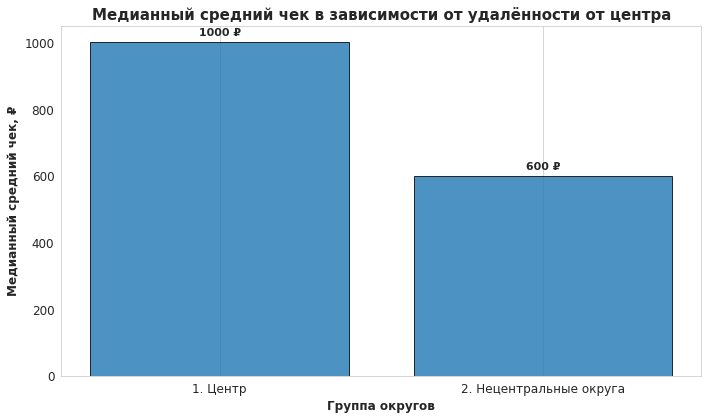

In [86]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    distance_stats['distance_group'],
    distance_stats['median_bill'],
    edgecolor='black',
    alpha=0.8
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 20,
        f'{int(height)} ₽',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title('Медианный средний чек в зависимости от удалённости от центра',
          fontsize=15, fontweight='bold')
plt.xlabel('Группа округов', fontsize=12, fontweight='bold')
plt.ylabel('Медианный средний чек, ₽', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

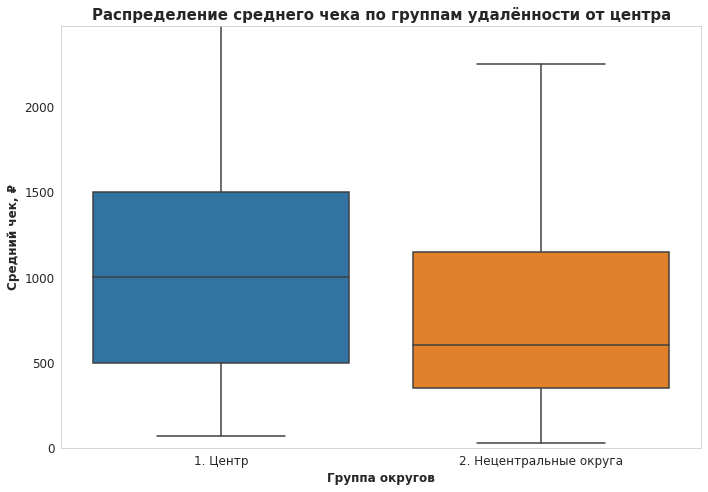

In [87]:
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=df_task8,
    x='distance_group',
    y='middle_avg_bill',
    order=['1. Центр', '2. Нецентральные округа']
)

plt.title('Распределение среднего чека по группам удалённости от центра',
          fontsize=15, fontweight='bold')
plt.xlabel('Группа округов', fontsize=12, fontweight='bold')
plt.ylabel('Средний чек, ₽', fontsize=12, fontweight='bold')

plt.ylim(0, df_task8['middle_avg_bill'].quantile(0.95) * 1.1)

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Наибольший медианный средний чек в ЦАО — 1000 ₽. Наименьший медианный средний чек в Юго-Восточном административном округе — 450 ₽.

Медианный средний чек в ЦАО составляет 1000 ₽, а в остальных округах — 600 ₽. В ЦАО медианный средний чек выше на 400 ₽. Расположение заведения связано с уровнем среднего чека. Центральные районы характеризуются более высокими ценами, что может быть связано с высокой арендной стоимостью, туристическим потоком, деловой активностью и концентрацией заведений более высокого ценового сегмента. По мере удаления от центра средний чек снижается, однако эта зависимость не является абсолютно строгой, так как на цены также влияют и категория заведения, формат обслуживания, известность сети и целевая аудитория.

---

### Промежуточный вывод

В ходе исследовательского анализа были изучены основные характеристики заведений общественного питания Москвы: категории заведений, распределение по административным округам, соотношение сетевых и несетевых объектов, количество посадочных мест, рейтинги, связь рейтинга с различными признаками, популярные сети и уровень среднего чека по округам.

- В данных представлены 8 категорий заведений. Наиболее распространёнными оказались кафе, рестораны и кофейни: именно они формируют основную часть рынка общественного питания. Реже всего встречаются булочные и столовые. Это может говорить о том, что универсальные форматы заведений, такие как кафе и рестораны, представлены на рынке шире, чем более специализированные форматы.

- По административным округам наибольшая концентрация заведений наблюдается в Центральном административном округе: в нём расположено 2242 заведений, что составляет около 26.7% от всех объектов в подготовленном датафрейме. В ЦАО особенно заметна доля ресторанов, кофеен и баров/пабов. Это логично, поскольку центр Москвы характеризуется высокой деловой, туристической и развлекательной активностью. Наименьшее количество заведений представлено в Северо-Западном административном округе.

- Анализ сетевых и несетевых заведений показал, что несетевых объектов больше: 61.9% от общего числа. Сетевые заведения составляют 38,1%. При этом доля сетевых объектов заметно различается по категориям: чаще всего сетевыми являются булочные, пиццерии и кофейни, а реже всего — бары/пабы. Это может быть связано с тем, что форматы булочных, пиццерий и кофеен легче стандартизировать и масштабировать.

- Количество посадочных мест имеет заметные выбросы. Медианное значение составляет 80 мест, при этом встречаются как очень маленькие заведения на 1–2 места, так и аномально крупные значения, например 1288 мест. Такие выбросы могут быть связаны с особенностями заполнения данных, объектами в торговых центрах, фудхоллами или техническими ошибками. По медианному количеству мест наиболее вместительными являются рестораны, бары/пабы и кофейни, а меньшие типичные значения характерны для булочных, кафе и пиццерий.

- Средний рейтинг заведений составляет 4.23, медианный — 4.30. В целом рейтинги разных категорий отличаются не сильно. Более высокие средние оценки наблюдаются у баров/пабов, пиццерий и ресторанов, а более низкие — у кафе и заведений быстрого питания. Это говорит о том, что категория заведения влияет на рейтинг, но различия между типами общепита не являются резкими.

- Анализ связи рейтинга с признаками показал, что наиболее заметная связь наблюдается с ценовой категорией. Коэффициент связи составил около 0.281, что указывает на слабую, но заметную зависимость: заведения с ценами выше среднего и высокими ценами в среднем имеют более высокий рейтинг. Также слабая связь рейтинга наблюдается с административным округом и категорией заведения. При этом ни один из рассмотренных факторов не оказывает сильного влияния на рейтинг, поэтому рейтинг нельзя объяснить только одним признаком.

- Среди популярных сетей лидером стала «Шоколадница» — 120 заведений со средним рейтингом 4.18. В топ-15 сетей чаще всего попадают кофейни, кафе, рестораны и пиццерии. При этом популярность сети не означает автоматически высокий рейтинг: крупные сети часто имеют оценки, близкие к среднему уровню.

- Анализ среднего чека показал выраженное отличие Центрального административного округа от остальных округов. Медианный средний чек в ЦАО составляет 1000 ₽, тогда как в остальных округах — 600 ₽. Это подтверждает, что расположение заведения связано с уровнем цен: в центральных районах цены выше, вероятно, из-за высокой аренды, туристического потока, деловой активности и концентрации заведений более высокого ценового сегмента.

## 4. Итоговый вывод и рекомендации

# Общий обзор
В рамках проекта был проведён исследовательский анализ данных о заведениях общественного питания Москвы. На первом этапе были загружены и изучены два датасета: основной датасет с информацией о заведениях и дополнительный датасет с данными о ценах. Затем данные были объединены в единый датафрейм, после чего выполнена предобработка: проверены типы данных, обработаны пропуски, удалены неявные дубликаты, нормализованы текстовые поля, а также создан дополнительный признак is_24_7, отражающий круглосуточный режим работы заведения.

После предобработки в итоговом датафрейме осталось 8401 заведений. Данные были подготовлены для дальнейшего анализа: ключевые пропуски в количестве посадочных мест, ценовой категории и среднем чеке были обработаны, а неинформативные или трудно восстанавливаемые пропуски в отдельных ценовых полях оставлены без заполнения.

В ходе исследовательского анализа были рассмотрены категории заведений, распределение объектов по административным округам, соотношение сетевых и несетевых заведений, количество посадочных мест, рейтинг, факторы, связанные с рейтингом, популярные сети Москвы и различия среднего чека по округам.

# Главные выводы
Основу рынка общественного питания Москвы составляют кафе, рестораны и кофейни. Эти категории наиболее многочисленны и, вероятно, наиболее универсальны с точки зрения спроса. Менее распространены булочные, столовые, пиццерии, заведения быстрого питания и бары/пабы.

Наибольшая концентрация заведений наблюдается в Центральном административном округе (2242 шт.). В ЦАО расположено около 26.7% всех заведений из подготовленного набора данных. Для центра особенно характерны рестораны, кофейни и бары/пабы. Это делает ЦАО наиболее насыщенной и конкурентной зоной, но одновременно и наиболее привлекательной с точки зрения потока посетителей.

Несетевых заведений в Москве больше, чем сетевых: 61.9% против 38.1%. Однако в отдельных категориях сетевой формат выражен сильнее. Чаще всего сетевыми являются булочные, пиццерии и кофейни. Это говорит о том, что данные форматы лучше подходят для масштабирования, стандартизации меню, интерьера, обслуживания и операционных процессов.

По количеству посадочных мест данные имеют заметные выбросы. Типичное значение лучше оценивать по медиане, которая составила 80 мест. Рестораны, бары/пабы и кофейни в среднем имеют больше посадочных мест, тогда как кафе, булочные и пиццерии чаще представлены более компактными форматами.

Средний рейтинг заведений достаточно высокий: около 4.23. Существенных различий между категориями заведений не обнаружено. Бары/пабы, пиццерии и рестораны имеют немного более высокие средние рейтинги, а кафе и быстрое питание — немного более низкие. Однако в целом оценки разных типов заведений находятся близко друг к другу.

Наиболее заметная связь рейтинга обнаружена с ценовой категорией. Заведения с ценами выше среднего и высокими ценами имеют более высокий средний рейтинг. Тем не менее связь остаётся слабой, поэтому нельзя утверждать, что высокий рейтинг определяется только ценой. На оценку пользователей, вероятно, дополнительно влияют качество кухни, сервис, расположение, атмосфера, известность бренда и ожидания аудитории.

Среди популярных сетей лидером стала «Шоколадница», представленная 120 заведениями. В топ-15 популярных сетей чаще всего входят кофейни, кафе, рестораны и пиццерии. При этом количество заведений в сети не гарантирует высокий рейтинг: масштаб сети скорее отражает распространённость бренда, чем однозначное преимущество по пользовательским оценкам.

Средний чек заметно зависит от расположения. В Центральном административном округе медианный средний чек составляет 1000 ₽, а в остальных округах — 600 ₽. Следовательно, в центре цены существенно выше. Это может быть связано с более высокой стоимостью аренды, туристическим и деловым трафиком, а также концентрацией заведений среднего и высокого ценового сегмента. По мере удаления от центра средний чек, как правило, снижается, хотя эта зависимость не является абсолютно строгой.

# Рекомендации
Если заказчик планирует открытие нового заведения, выбор района и формата должен зависеть от желаемой концепции и ценового позиционирования.

Для заведения с высоким или выше среднего чеком наиболее перспективным может быть Центральный административный округ. В центре уже сформирована аудитория, готовая платить больше, а также присутствует высокий поток потенциальных посетителей. Однако следует учитывать и высокий уровень конкуренции: в ЦАО сосредоточено много ресторанов (670 шт.), кафе (464 шт.), кофеен (428 шт.) и баров/пабов (324 шт.), поэтому новому заведению потребуется чёткое позиционирование, сильная концепция, качественный сервис и заметное отличие от конкурентов. 

Если цель — открыть более массовое заведение со средним чеком, можно рассматривать нецентральные округа. В них ниже медианный средний чек (1000 руб. против 600 руб.), но при этом конкуренция может быть менее плотной, чем в центре (в центре 2242 шт. заведений, в остальных районах 409-897 шт.). Для такого варианта особенно важно выбирать локации с устойчивым пешеходным трафиком: рядом с метро, жилыми кварталами, офисными зонами, торговыми центрами или учебными заведениями.

В плане формата перспективными выглядят кафе, кофейни и рестораны, поскольку они являются наиболее распространёнными категориями (2376, 1412, 2042 шт. соотв.). Но из-за высокой представленности этих форматов важно заранее продумать уникальное торговое предложение. Для кофейни или кафе это может быть удобная локация, быстрый сервис, качественный кофе, завтраки, рабочая атмосфера или формат «рядом с домом». Для ресторана — кухня, интерьер, уровень обслуживания и ориентация на конкретную аудиторию.

Если рассматривается сетевая модель, то наиболее подходящими форматами могут быть кофейни, пиццерии и булочные. Эти категории чаще представлены сетевыми заведениями (50.9, 52.1, 61.3% соотв.), что говорит об их пригодности для масштабирования. Для таких форматов особенно важны стандартизированное меню, понятная ценовая политика, узнаваемость бренда и повторяемость клиентского опыта в разных точках.

Не стоит ориентироваться только на рейтинг как на главный показатель успешности заведения. Анализ показал, что рейтинг слабо связан с отдельными признаками, такими как категория, округ, количество посадочных мест или сетевой статус. Поэтому при принятии решения стоит дополнительно учитывать проходимость локации, конкуренцию, арендную ставку, целевую аудиторию, формат обслуживания и экономику проекта.

Скорее всего наиболее подходящей стратегией для заказчика может быть открытие заведения среднего или выше среднего ценового сегмента в районе с высоким трафиком, но не обязательно в самой насыщенной части ЦАО. Если же выбран именно центр Москвы, заведению потребуется более сильная концепция и качественная проработка конкурентных преимуществ, поскольку высокий средний чек в центре сопровождается высокой конкуренцией.